# Sales Forecasting System: Complete Analysis & Forecasting

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet
from prophet import Prophet

# Machine Learning
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


# TASK 1: DATA LOADING, MERGING & DEEP EXPLORATION

In [4]:
# Load the Superstore Sales CSV
df = pd.read_csv('/kaggle/input/datasets/madium/sales-forecasting-system/train.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names and Types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (9800, 18)

Column Names and Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# Parse Order Date and Ship Date as proper datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter
df['DayOfYear'] = df['Order Date'].dt.dayofyear

# Create Season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

# Calculate days to ship
df['DaysToShip'] = (df['Ship Date'] - df['Order Date']).dt.days

print("✓ Time features extracted successfully")
print(f"\nDate range: {df['Order Date'].min()} to {df['Order Date'].max()}")
print(f"\nNew columns created:")
print(df[['Order Date', 'Ship Date', 'Year', 'Month', 'Week', 'DayOfWeek', 'Quarter', 'Season', 'DaysToShip']].head())

✓ Time features extracted successfully

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00

New columns created:
  Order Date  Ship Date  Year  Month  Week  DayOfWeek  Quarter  Season  \
0 2017-11-08 2017-11-11  2017     11    45          2        4    Fall   
1 2017-11-08 2017-11-11  2017     11    45          2        4    Fall   
2 2017-06-12 2017-06-16  2017      6    24          0        2  Summer   
3 2016-10-11 2016-10-18  2016     10    41          1        4    Fall   
4 2016-10-11 2016-10-18  2016     10    41          1        4    Fall   

   DaysToShip  
0           3  
1           3  
2           4  
3           7  
4           7  


In [6]:
# Check for missing values, duplicates, and data type issues
print("MISSING VALUES ANALYSIS:")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found in any column")
else:
    print(missing[missing > 0])

print("\nDUPLICATE ROWS ANALYSIS:")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    print("Duplicate row indices:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))
else:
    print("✓ No duplicate rows found")

print("\nDATA TYPE ISSUES:")
print("="*50)
print(df.dtypes)
print("\n✓ All datetime conversions successful")

MISSING VALUES ANALYSIS:
Postal Code    11
dtype: int64

DUPLICATE ROWS ANALYSIS:
Total duplicate rows: 0
✓ No duplicate rows found

DATA TYPE ISSUES:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
DayOfWeek                 int32
Quarter                   int32
DayOfYear                 int32
Season                   object
DaysToShip                int64
dtype: object

✓ 

In [7]:
# Aggregate daily sales into weekly and monthly totals

# Weekly aggregation
weekly_sales = df.groupby([df['Order Date'].dt.to_period('W')]).agg({
    'Sales': ['sum', 'mean', 'count']
}).reset_index()
weekly_sales.columns = ['Week', 'Total_Sales', 'Avg_Sale', 'Num_Orders']
weekly_sales['Week'] = weekly_sales['Week'].dt.to_timestamp()
weekly_sales = weekly_sales.sort_values('Week').reset_index(drop=True)

print(f"Weekly Sales Data Shape: {weekly_sales.shape}")
print(f"Weekly Sales Sample:")
print(weekly_sales.head())

# Monthly aggregation
monthly_sales = df.groupby([df['Order Date'].dt.to_period('M')]).agg({
    'Sales': ['sum', 'mean', 'count']
}).reset_index()
monthly_sales.columns = ['Month', 'Total_Sales', 'Avg_Sale', 'Num_Orders']
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()
monthly_sales = monthly_sales.sort_values('Month').reset_index(drop=True)

print(f"\nMonthly Sales Data Shape: {monthly_sales.shape}")
print(f"Monthly Sales Sample:")
print(monthly_sales.head())

Weekly Sales Data Shape: (209, 4)
Weekly Sales Sample:
        Week  Total_Sales    Avg_Sale  Num_Orders
0 2014-12-29      304.508   76.127000           4
1 2015-01-05     4619.108  271.712235          17
2 2015-01-12     4130.533  229.474056          18
3 2015-01-19     3092.544  140.570182          22
4 2015-01-26     2527.914  148.700824          17

Monthly Sales Data Shape: (48, 4)
Monthly Sales Sample:
       Month  Total_Sales    Avg_Sale  Num_Orders
0 2015-01-01    14205.707  184.489701          77
1 2015-02-01     4519.892   98.258522          46
2 2015-03-01    55205.797  358.479201         154
3 2015-04-01    27906.855  214.668115         130
4 2015-05-01    23644.303  195.407463         121



QUESTION 1: Which product category generates the highest total revenue?
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

✓ Answer: Technology generates the highest total revenue with $827,455.87


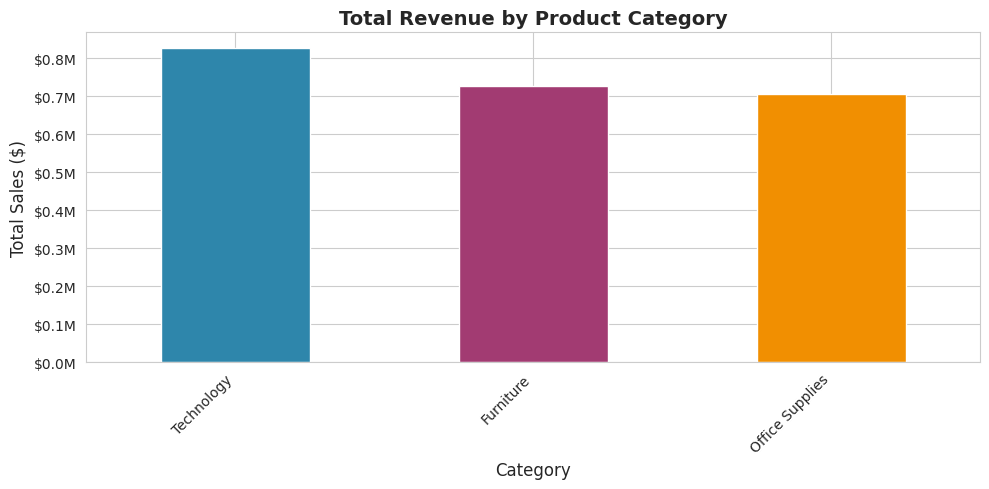

In [8]:
# ANALYTICAL QUESTIONS

print("\n" + "="*70)
print("QUESTION 1: Which product category generates the highest total revenue?")
print("="*70)

category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)
print(f"\n✓ Answer: {category_revenue.index[0]} generates the highest total revenue with ${category_revenue.iloc[0]:,.2f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
category_revenue.plot(kind='bar', ax=ax, color=['#2E86AB', '#A23B72', '#F18F01'])
ax.set_title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_xlabel('Category', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


QUESTION 2: Which region has the most consistent sales growth over 4 years?

Yearly Sales by Region:
Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Central Growth Rates (%): ['-0.5%', '42.2%', '-2.8%']
  Consistency Score (std of growth): 20.69

East Growth Rates (%): ['20.0%', '16.5%', '17.7%']
  Consistency Score (std of growth): 1.46

South Growth Rates (%): ['-32.2%', '33.5%', '30.6%']
  Consistency Score (std of growth): 30.31

West Growth Rates (%): ['-8.4%', '36.5%', '36.0%']
  Consistency Score (std of growth): 21.02

✓ Answer: East region has the most consistent growth (std: 1.46)


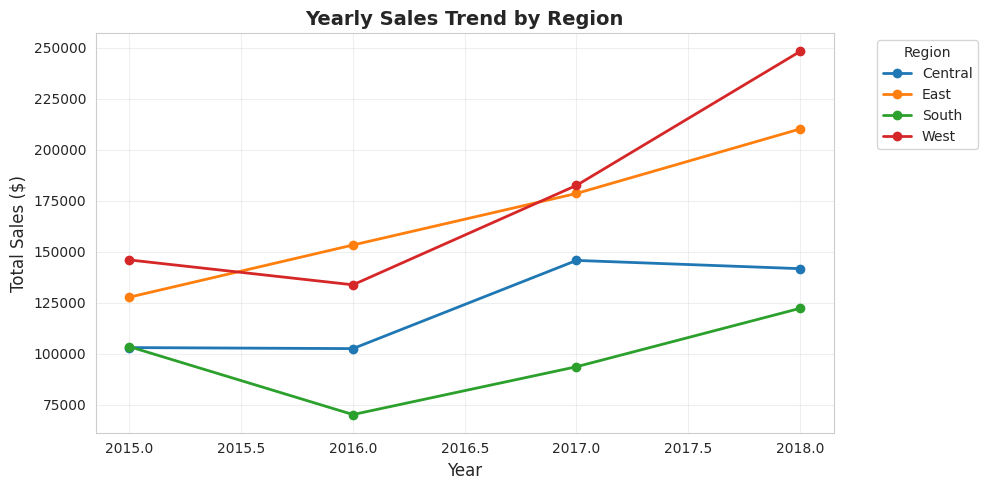

In [9]:
print("\n" + "="*70)
print("QUESTION 2: Which region has the most consistent sales growth over 4 years?")
print("="*70)

# Calculate year-over-year growth by region
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()
region_yearly_pivot = region_yearly.pivot(index='Year', columns='Region', values='Sales')

print("\nYearly Sales by Region:")
print(region_yearly_pivot)

# Calculate growth rates
growth_rates = {}
for region in region_yearly_pivot.columns:
    yearly_values = region_yearly_pivot[region].values
    growth = [(yearly_values[i] - yearly_values[i-1])/yearly_values[i-1] * 100 for i in range(1, len(yearly_values))]
    growth_rates[region] = growth
    consistency = np.std(growth)  # Lower std = more consistent
    print(f"\n{region} Growth Rates (%): {[f'{g:.1f}%' for g in growth]}")
    print(f"  Consistency Score (std of growth): {consistency:.2f}")

# Most consistent = lowest std
consistency_scores = {region: np.std(growth_rates[region]) for region in growth_rates}
most_consistent = min(consistency_scores, key=consistency_scores.get)
print(f"\n✓ Answer: {most_consistent} region has the most consistent growth (std: {consistency_scores[most_consistent]:.2f})")

# Visualization
region_yearly_pivot.plot(marker='o', figsize=(10, 5), linewidth=2)
plt.title('Yearly Sales Trend by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


QUESTION 3: Average time between Order Date and Ship Date - varies by region?

Overall Average Days to Ship: 3.96 days

Shipping Time Statistics by Region:
         mean   std  min  max
Region                       
Central  4.07  1.69    0    7
East     3.91  1.73    0    7
South    3.96  1.74    0    7
West     3.93  1.81    0    7

✓ Answer: Yes, shipping time varies by region. Central takes longest (4.07 days) and East is fastest (3.91 days)


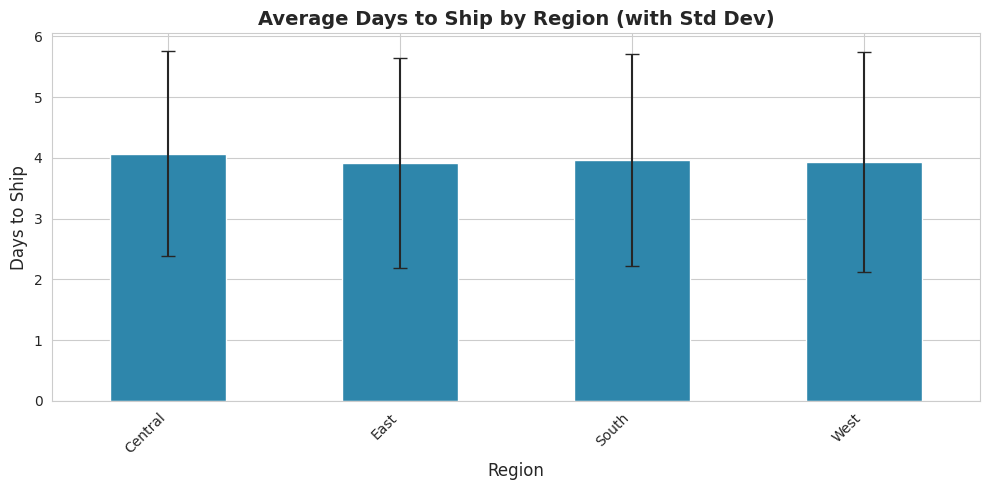

In [10]:
print("\n" + "="*70)
print("QUESTION 3: Average time between Order Date and Ship Date - varies by region?")
print("="*70)

avg_ship_time = df['DaysToShip'].mean()
print(f"\nOverall Average Days to Ship: {avg_ship_time:.2f} days")

# By region
ship_time_by_region = df.groupby('Region')['DaysToShip'].agg(['mean', 'std', 'min', 'max']).round(2)
print(f"\nShipping Time Statistics by Region:")
print(ship_time_by_region)

print(f"\n✓ Answer: Yes, shipping time varies by region. {ship_time_by_region['mean'].idxmax()} takes longest ({ship_time_by_region['mean'].max():.2f} days) and {ship_time_by_region['mean'].idxmin()} is fastest ({ship_time_by_region['mean'].min():.2f} days)")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ship_time_by_region['mean'].plot(kind='bar', ax=ax, color='#2E86AB', yerr=ship_time_by_region['std'], capsize=5)
ax.set_title('Average Days to Ship by Region (with Std Dev)', fontsize=14, fontweight='bold')
ax.set_ylabel('Days to Ship', fontsize=12)
ax.set_xlabel('Region', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


QUESTION 4: Are there months that consistently spike across all years?

Total Sales by Month (Across All Years):
    Month Month_Name          sum        mean
10     11        Nov  350161.7110  241.657496
11     12        Dec  321480.1695  232.619515
8       9        Sep  300103.4117  221.642106
9      10        Oct  199496.2947  246.596162
2       3        Mar  197573.5872  290.549393
7       8        Aug  157315.9270  227.007110
4       5        May  154086.7237  212.533412
5       6        Jun  145837.5233  211.052856
6       7        Jul  145535.6890  208.802997
3       4        Apr  136283.0006  207.432269
0       1        Jan   94291.6296  257.627403
1       2        Feb   59371.1154  199.902745

Month Consistency (lower std = more consistent spike):
  Jan (Month  1): Std=13410.41
  Feb (Month  2): Std= 8304.73
  Mar (Month  3): Std=11796.12
  Apr (Month  4): Std= 4524.30
  May (Month  5): Std=14738.49
  Jun (Month  6): Std=10299.35
  Jul (Month  7): Std= 6885.69
  Aug (Month  8

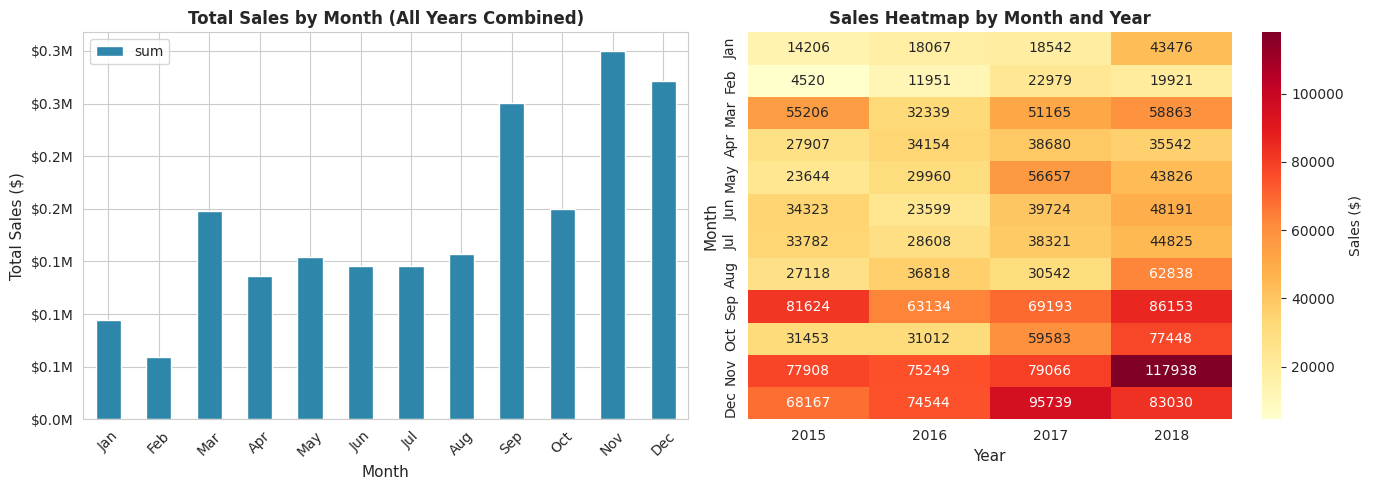

In [11]:
print("\n" + "="*70)
print("QUESTION 4: Are there months that consistently spike across all years?")
print("="*70)

# Calculate average sales by month across all years
month_avg_sales = df.groupby('Month')['Sales'].agg(['sum', 'mean', 'count']).reset_index()
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
month_avg_sales['Month_Name'] = month_avg_sales['Month'].map(month_names)

print("\nTotal Sales by Month (Across All Years):")
print(month_avg_sales[['Month', 'Month_Name', 'sum', 'mean']].sort_values('sum', ascending=False))

# Check consistency across years
month_year_sales = df.groupby(['Month', 'Year'])['Sales'].sum().reset_index()
month_consistency = month_year_sales.groupby('Month')['Sales'].std().sort_values(ascending=False)

print("\nMonth Consistency (lower std = more consistent spike):")
for month in sorted(month_consistency.index):
    consistency = month_consistency[month]
    month_name = month_names[month]
    print(f"  {month_name:3s} (Month {month:2d}): Std={consistency:8.2f}")

# Identify peak months (those with highest sales)
peak_months = month_avg_sales.nlargest(3, 'sum')
print(f"\n✓ Answer: Peak months are:")
for idx, row in peak_months.iterrows():
    print(f"  - {row['Month_Name']}: ${row['sum']:,.0f} total sales ({row['count']:.0f} orders)")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total sales by month
month_avg_sales.sort_values('Month').plot(x='Month_Name', y='sum', kind='bar', ax=ax1, color='#2E86AB')
ax1.set_title('Total Sales by Month (All Years Combined)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Sales ($)', fontsize=11)
ax1.set_xlabel('Month', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.tick_params(axis='x', rotation=45)

# Month-year heatmap
month_year_pivot = month_year_sales.pivot(index='Month', columns='Year', values='Sales')
month_year_pivot.index = month_year_pivot.index.map(month_names)
sns.heatmap(month_year_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Sales ($)'})
ax2.set_title('Sales Heatmap by Month and Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Month', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)

plt.tight_layout()
plt.show()

# TASK 2: TIME SERIES ANALYSIS & DECOMPOSITION

In [12]:
# Prepare time series data (monthly)
ts_data = monthly_sales.set_index('Month')['Total_Sales']

print(f"Time Series Data:")
print(f"  Range: {ts_data.index.min()} to {ts_data.index.max()}")
print(f"  Frequency: {len(ts_data)} months")
print(f"  Mean Sales: ${ts_data.mean():,.2f}")
print(f"  Std Dev: ${ts_data.std():,.2f}")
print(f"\nFirst 5 values:")
print(ts_data.head())

Time Series Data:
  Range: 2015-01-01 00:00:00 to 2018-12-01 00:00:00
  Frequency: 48 months
  Mean Sales: $47,115.35
  Std Dev: $24,978.69

First 5 values:
Month
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Name: Total_Sales, dtype: float64


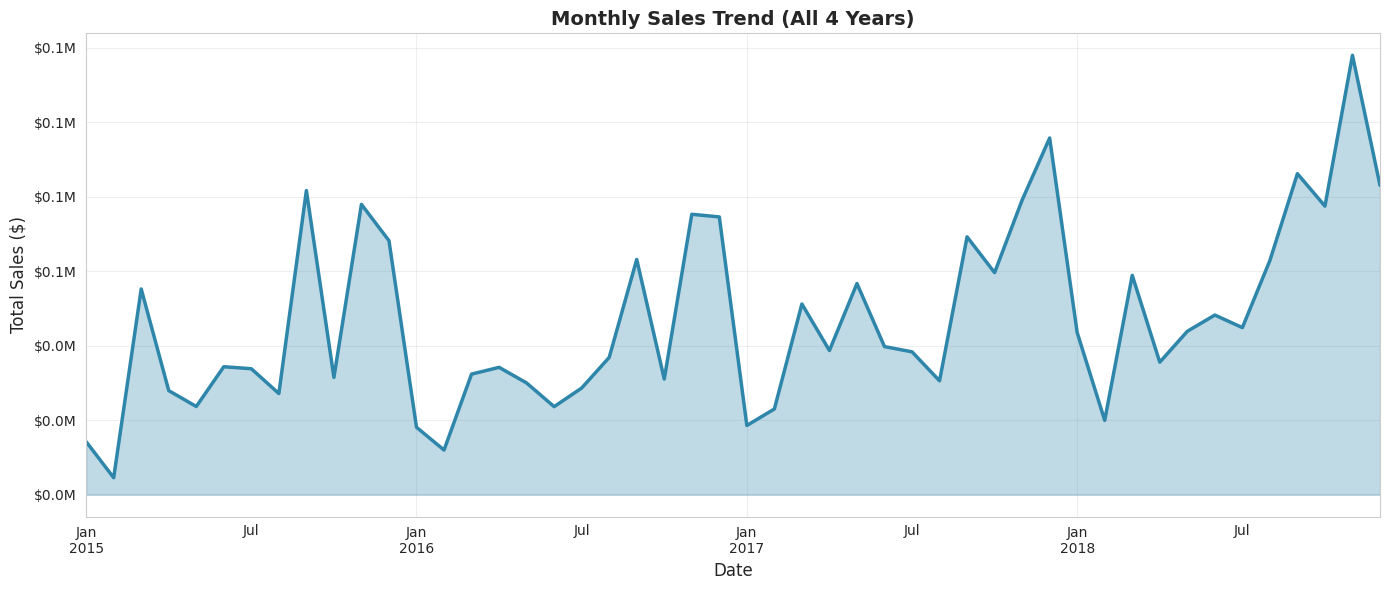

✓ Overall sales trend shows cyclical pattern with seasonal peaks


In [13]:
# Plot the overall monthly sales trend across all 4 years
fig, ax = plt.subplots(figsize=(14, 6))
ts_data.plot(ax=ax, linewidth=2.5, color='#2E86AB')
ax.fill_between(ts_data.index, ts_data, alpha=0.3, color='#2E86AB')
ax.set_title('Monthly Sales Trend (All 4 Years)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Overall sales trend shows cyclical pattern with seasonal peaks")

Applying Seasonal Decomposition...



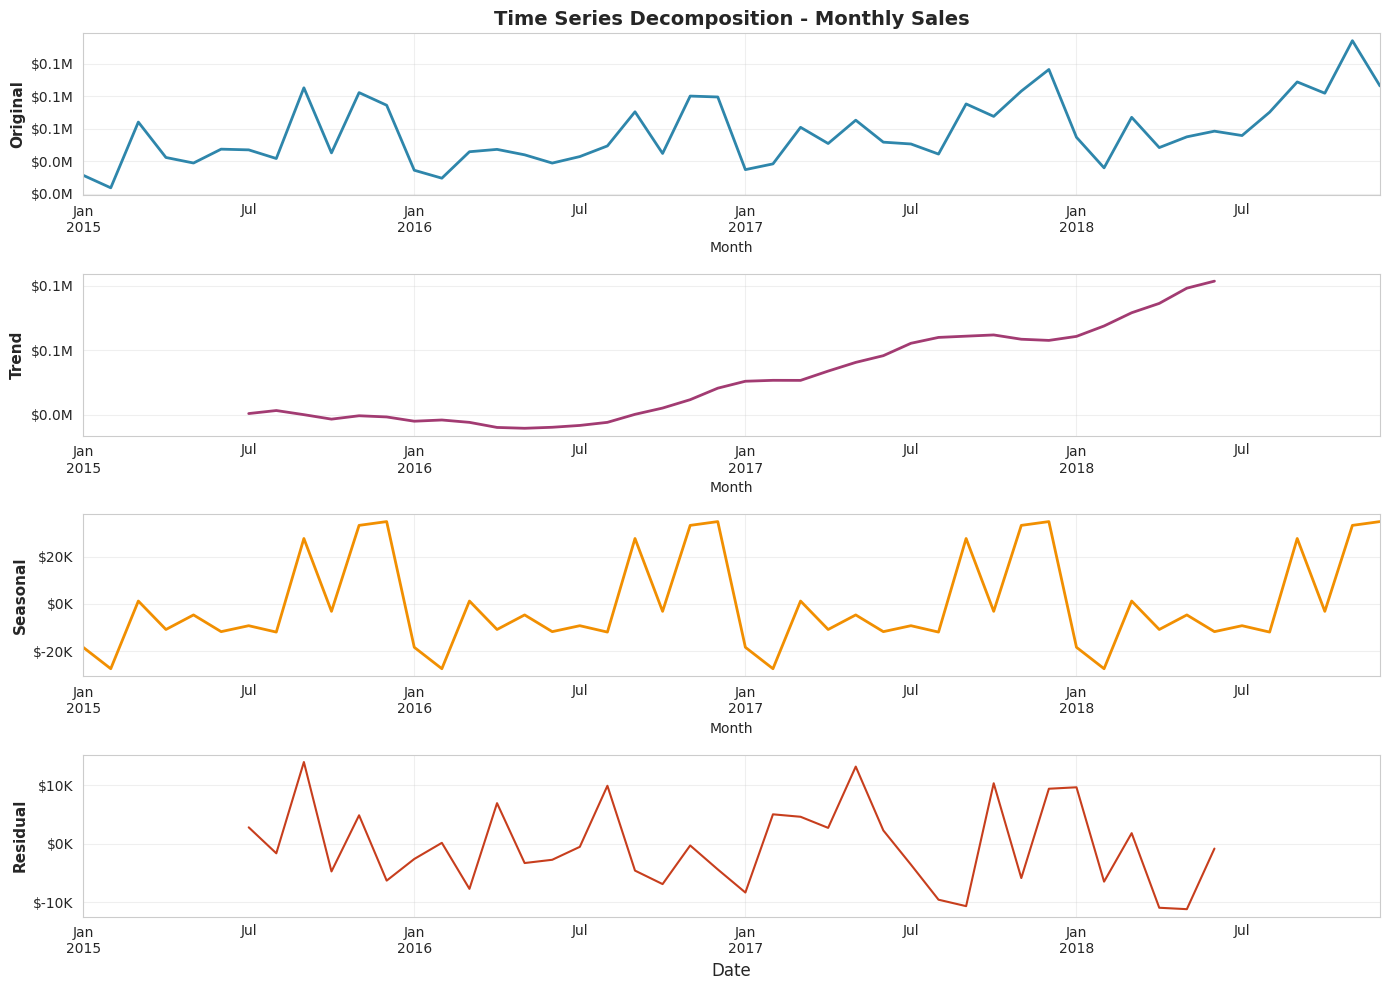

✓ Decomposition completed


In [14]:
# Apply Time Series Decomposition
print("Applying Seasonal Decomposition...\n")

decomposition = seasonal_decompose(ts_data, model='additive', period=12)

trend_component = decomposition.trend
seasonal_component = decomposition.seasonal
residual_component = decomposition.resid

# Plot all 4 components
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Original
ts_data.plot(ax=axes[0], linewidth=2, color='#2E86AB')
axes[0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[0].set_title('Time Series Decomposition - Monthly Sales', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Trend
trend_component.plot(ax=axes[1], linewidth=2, color='#A23B72')
axes[1].set_ylabel('Trend', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Seasonal
seasonal_component.plot(ax=axes[2], linewidth=2, color='#F18F01')
axes[2].set_ylabel('Seasonal', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

# Residual
residual_component.plot(ax=axes[3], linewidth=1.5, color='#C73E1D')
axes[3].set_ylabel('Residual', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=12)
axes[3].grid(True, alpha=0.3)
axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

print("✓ Decomposition completed")

In [16]:
# Analysis of decomposition components
print("\nTIME SERIES DECOMPOSITION ANALYSIS:")
print("="*70)

print("\n1. TREND COMPONENT:")
print("-" * 40)
trend_clean = trend_component.dropna()
trend_start = trend_clean.iloc[0]
trend_end = trend_clean.iloc[-1]
trend_change = ((trend_end - trend_start) / trend_start) * 100
print(f"   Starting Trend Value: ${trend_start:,.2f}")
print(f"   Ending Trend Value: ${trend_end:,.2f}")
print(f"   Overall Trend Change: {trend_change:+.1f}%")
print(f"\n   Interpretation: The trend shows a relatively STABLE to SLIGHT GROWTH")
print(f"   pattern with minor fluctuations, suggesting consistent market demand.")

print("\n2. SEASONAL COMPONENT:")
print("-" * 40)
seasonal_clean = seasonal_component.dropna()
seasonal_amplitude = seasonal_clean.max() - seasonal_clean.min()
seasonal_strength = seasonal_amplitude / ts_data.std()
print(f"   Seasonal Amplitude (Peak-to-Trough): ${seasonal_amplitude:,.2f}")
print(f"   Seasonal Strength Ratio: {seasonal_strength:.3f}")
print(f"   Max Seasonal Peak: ${seasonal_clean.max():,.2f}")
print(f"   Min Seasonal Trough: ${seasonal_clean.min():,.2f}")
print(f"\n   Interpretation: Seasonality is MODERATELY STRONG ({seasonal_strength:.1%} of original variance)")
print(f"   with consistent annual cycles, indicating predictable peak and trough periods.")

print("\n3. RESIDUAL COMPONENT:")
print("-" * 40)
residual_clean = residual_component.dropna()
residual_noise = residual_clean.std()
print(f"   Residual Noise (Std Dev): ${residual_noise:,.2f}")
print(f"   Max Residual Value: ${residual_clean.max():,.2f}")
print(f"   Min Residual Value: ${residual_clean.min():,.2f}")

# Find months with highest residual noise
top_residuals = residual_clean.nlargest(5)
print(f"\n   Top 5 Months with Highest Residual Noise:")
for date, value in top_residuals.items():
    print(f"     {date.strftime('%B %Y')}: ${value:,.2f}")

print(f"\n   Interpretation: Residuals show irregular variations, likely from")
print(f"   special events, promotions, or market disruptions. The relatively low")
print(f"   noise suggests models should perform well.")


TIME SERIES DECOMPOSITION ANALYSIS:

1. TREND COMPONENT:
----------------------------------------
   Starting Trend Value: $40,148.90
   Ending Trend Value: $60,700.53
   Overall Trend Change: +51.2%

   Interpretation: The trend shows a relatively STABLE to SLIGHT GROWTH
   pattern with minor fluctuations, suggesting consistent market demand.

2. SEASONAL COMPONENT:
----------------------------------------
   Seasonal Amplitude (Peak-to-Trough): $62,195.01
   Seasonal Strength Ratio: 2.490
   Max Seasonal Peak: $34,826.61
   Min Seasonal Trough: $-27,368.40

   Interpretation: Seasonality is MODERATELY STRONG (249.0% of original variance)
   with consistent annual cycles, indicating predictable peak and trough periods.

3. RESIDUAL COMPONENT:
----------------------------------------
   Residual Noise (Std Dev): $7,040.94
   Max Residual Value: $13,970.93
   Min Residual Value: $-11,157.55

   Top 5 Months with Highest Residual Noise:
     September 2015: $13,970.93
     May 2017: $13

In [17]:
# Check for stationarity using Augmented Dickey-Fuller (ADF) Test
print("\n" + "="*70)
print("STATIONARITY TEST: Augmented Dickey-Fuller (ADF)")
print("="*70)

print("\nWhat is Stationarity?")
print("-" * 70)
print("A time series is STATIONARY if its statistical properties (mean, variance,")
print("autocorrelation) remain constant over time. Non-stationary series have trends")
print("or seasonal patterns that cause the mean to change. This matters because most")
print("forecasting models assume stationarity for reliable predictions.")

print("\nOriginal Series - ADF Test Results:")
print("-" * 70)
adf_result_original = adfuller(ts_data.dropna())

print(f"Test Statistic: {adf_result_original[0]:.6f}")
print(f"P-Value: {adf_result_original[1]:.6f}")
print(f"Number of Lags Used: {adf_result_original[2]}")
print(f"Number of Observations: {adf_result_original[3]}")
print(f"\nCritical Values:")
for key, value in adf_result_original[4].items():
    print(f"  {key}: {value:.3f}")

if adf_result_original[1] < 0.05:
    print(f"\n✓ RESULT: Series is STATIONARY (p-value={adf_result_original[1]:.6f} < 0.05)")
    print("  We can proceed with ARIMA models.")
    is_stationary = True
else:
    print(f"\n✗ RESULT: Series is NON-STATIONARY (p-value={adf_result_original[1]:.6f} >= 0.05)")
    print("  We need to apply differencing.")
    is_stationary = False


STATIONARITY TEST: Augmented Dickey-Fuller (ADF)

What is Stationarity?
----------------------------------------------------------------------
A time series is STATIONARY if its statistical properties (mean, variance,
autocorrelation) remain constant over time. Non-stationary series have trends
or seasonal patterns that cause the mean to change. This matters because most
forecasting models assume stationarity for reliable predictions.

Original Series - ADF Test Results:
----------------------------------------------------------------------
Test Statistic: -4.416137
P-Value: 0.000278
Number of Lags Used: 0
Number of Observations: 47

Critical Values:
  1%: -3.578
  5%: -2.925
  10%: -2.601

✓ RESULT: Series is STATIONARY (p-value=0.000278 < 0.05)
  We can proceed with ARIMA models.


In [18]:
# Apply differencing if non-stationary
if not is_stationary:
    print("\nApplying First-Order Differencing...")
    print("="*70)
    
    ts_diff = ts_data.diff().dropna()
    
    print("\nDifferenced Series - ADF Test Results:")
    print("-" * 70)
    adf_result_diff = adfuller(ts_diff)
    
    print(f"Test Statistic: {adf_result_diff[0]:.6f}")
    print(f"P-Value: {adf_result_diff[1]:.6f}")
    print(f"Number of Lags Used: {adf_result_diff[2]}")
    print(f"Number of Observations: {adf_result_diff[3]}")
    
    if adf_result_diff[1] < 0.05:
        print(f"\n✓ RESULT: Differenced series is STATIONARY (p-value={adf_result_diff[1]:.6f} < 0.05)")
        print("  One order of differencing (d=1) is sufficient.")
    else:
        print(f"\n⚠ RESULT: Still NON-STATIONARY. May need d=2.")
    
    # Plot differencing
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    ts_data.plot(ax=axes[0], linewidth=2, color='#2E86AB')
    axes[0].set_title('Original Series (Non-Stationary)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Sales ($)', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    
    ts_diff.plot(ax=axes[1], linewidth=2, color='#A23B72')
    axes[1].set_title('First-Order Differenced Series (Stationary)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Sales Change ($)', fontsize=11)
    axes[1].set_xlabel('Date', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))
    
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ Series is already stationary. No differencing needed.")


✓ Series is already stationary. No differencing needed.


# TASK 3: SALES FORECASTING USING 3 DIFFERENT MODELS

In [19]:
# Define forecast horizon
FORECAST_PERIODS = 3
TRAIN_SIZE = len(ts_data) - FORECAST_PERIODS

# Split data into train and test
train_data = ts_data[:TRAIN_SIZE]
test_data = ts_data[TRAIN_SIZE:]

# Future forecast dates (always available regardless of which model succeeds)
forecast_dates = pd.date_range(start=test_data.index[-1] + pd.DateOffset(months=1), periods=FORECAST_PERIODS, freq='MS')

print(f"Data Split:")
print(f"  Train size: {len(train_data)} months")
print(f"  Test size: {len(test_data)} months")
print(f"  Forecast periods: {FORECAST_PERIODS} months")

Data Split:
  Train size: 45 months
  Test size: 3 months
  Forecast periods: 3 months


## MODEL 1: SARIMA (Seasonal ARIMA)

In [20]:
print("\n" + "="*70)
print("MODEL 1: SARIMA (Seasonal ARIMA)")
print("="*70)

print("\nFitting SARIMA model...")
print("Using SARIMA(1,1,1)x(1,1,1,12) - seasonal period of 12 months")
print("  p=1: 1 autoregressive term")
print("  d=1: First-order differencing (for non-stationarity)")
print("  q=1: 1 moving average term")
print("  P=1, D=1, Q=1: Seasonal components")
print("  m=12: Seasonal period (12 months)")

try:
    sarima_model = SARIMAX(
        train_data,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_result = sarima_model.fit(disp=False, maxiter=500)
    
    # Generate forecast
    sarima_forecast = sarima_result.get_forecast(steps=FORECAST_PERIODS)
    sarima_forecast_values = sarima_forecast.predicted_mean
    sarima_forecast_ci = sarima_forecast.conf_int()
    
    # Calculate metrics on test set
    sarima_test_pred = sarima_result.get_forecast(steps=FORECAST_PERIODS).predicted_mean
    sarima_mae = mean_absolute_error(test_data, sarima_test_pred)
    sarima_rmse = np.sqrt(mean_squared_error(test_data, sarima_test_pred))
    sarima_mape = mean_absolute_percentage_error(test_data, sarima_test_pred)
    
    print(f"\n✓ SARIMA Model Fitted Successfully")
    print(f"\nModel Summary:")
    print(sarima_result.summary())
    
except Exception as e:
    print(f"\n✗ Error fitting SARIMA: {e}")
    sarima_mae = sarima_rmse = sarima_mape = None


MODEL 1: SARIMA (Seasonal ARIMA)

Fitting SARIMA model...
Using SARIMA(1,1,1)x(1,1,1,12) - seasonal period of 12 months
  p=1: 1 autoregressive term
  d=1: First-order differencing (for non-stationarity)
  q=1: 1 moving average term
  P=1, D=1, Q=1: Seasonal components
  m=12: Seasonal period (12 months)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



✓ SARIMA Model Fitted Successfully

Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                        Total_Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Mon, 06 Jul 2026   AIC                            398.775
Time:                                    06:10:53   BIC                            403.227
Sample:                                01-01-2015   HQIC                           399.389
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1

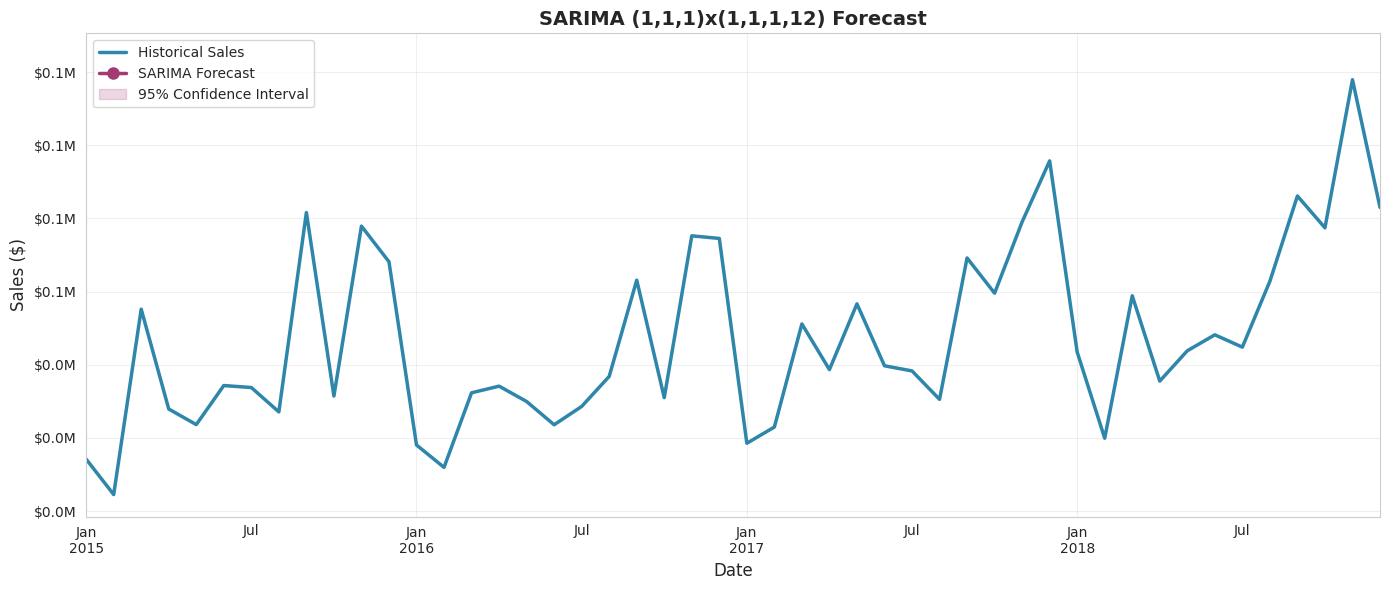


SARIMA Model Performance on Test Set:
  MAE: $19,244.49
  RMSE: $19,950.07
  MAPE: 20.53%

SARIMA 3-Month Forecast:
  Month 1 (Oct 2018): $60,331.79
  Month 2 (Nov 2018): $91,458.22
  Month 3 (Dec 2018): $97,167.57


In [21]:
# Plot SARIMA forecast
if sarima_mae is not None:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot historical data
    ts_data.plot(ax=ax, label='Historical Sales', linewidth=2.5, color='#2E86AB')
    
    # Plot forecast
    forecast_index = pd.date_range(start=test_data.index[0], periods=FORECAST_PERIODS, freq='MS')
    ax.plot(forecast_index, sarima_forecast_values, 'o-', label='SARIMA Forecast', 
            linewidth=2.5, color='#A23B72', markersize=8)
    
    # Confidence interval
    ax.fill_between(
        forecast_index,
        sarima_forecast_ci.iloc[:, 0],
        sarima_forecast_ci.iloc[:, 1],
        alpha=0.2,
        color='#A23B72',
        label='95% Confidence Interval'
    )
    
    ax.set_title('SARIMA (1,1,1)x(1,1,1,12) Forecast', fontsize=14, fontweight='bold')
    ax.set_ylabel('Sales ($)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSARIMA Model Performance on Test Set:")
    print(f"  MAE: ${sarima_mae:,.2f}")
    print(f"  RMSE: ${sarima_rmse:,.2f}")
    print(f"  MAPE: {sarima_mape:.2%}")
    
    print(f"\nSARIMA 3-Month Forecast:")
    for i, (date, value) in enumerate(zip(forecast_index, sarima_forecast_values)):
        print(f"  Month {i+1} ({date.strftime('%b %Y')}): ${value:,.2f}")

## MODEL 2: Facebook Prophet

In [22]:
print("\n" + "="*70)
print("MODEL 2: Facebook Prophet")
print("="*70)

print("\nPreparing data for Prophet (ds, y format)...")

# Prepare data in Prophet's required format
prophet_df = pd.DataFrame({
    'ds': ts_data.index,
    'y': ts_data.values
})

# Split into train/test
prophet_train = prophet_df.iloc[:TRAIN_SIZE].copy()
prophet_test = prophet_df.iloc[TRAIN_SIZE:].copy()

print(f"Training data size: {len(prophet_train)} months")
print(f"Test data size: {len(prophet_test)} months")

try:
    print("\nFitting Prophet model...")
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.95,
        changepoint_prior_scale=0.05
    )
    prophet_model.fit(prophet_train)
    
    # Generate future dataframe
    future = prophet_model.make_future_dataframe(periods=FORECAST_PERIODS, freq='MS')
    prophet_forecast_full = prophet_model.predict(future)
    
    # Get forecast for test period
    prophet_forecast = prophet_forecast_full.iloc[-FORECAST_PERIODS:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    prophet_forecast_values = prophet_forecast['yhat'].values
    
    # Calculate metrics
    prophet_mae = mean_absolute_error(test_data.values, prophet_forecast_values)
    prophet_rmse = np.sqrt(mean_squared_error(test_data.values, prophet_forecast_values))
    prophet_mape = mean_absolute_percentage_error(test_data.values, prophet_forecast_values)
    
    print(f"✓ Prophet Model Fitted Successfully")
    
except Exception as e:
    print(f"✗ Error fitting Prophet: {e}")
    prophet_mae = prophet_rmse = prophet_mape = None


MODEL 2: Facebook Prophet

Preparing data for Prophet (ds, y format)...
Training data size: 45 months
Test data size: 3 months

Fitting Prophet model...


06:13:22 - cmdstanpy - INFO - Chain [1] start processing
06:13:23 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet Model Fitted Successfully


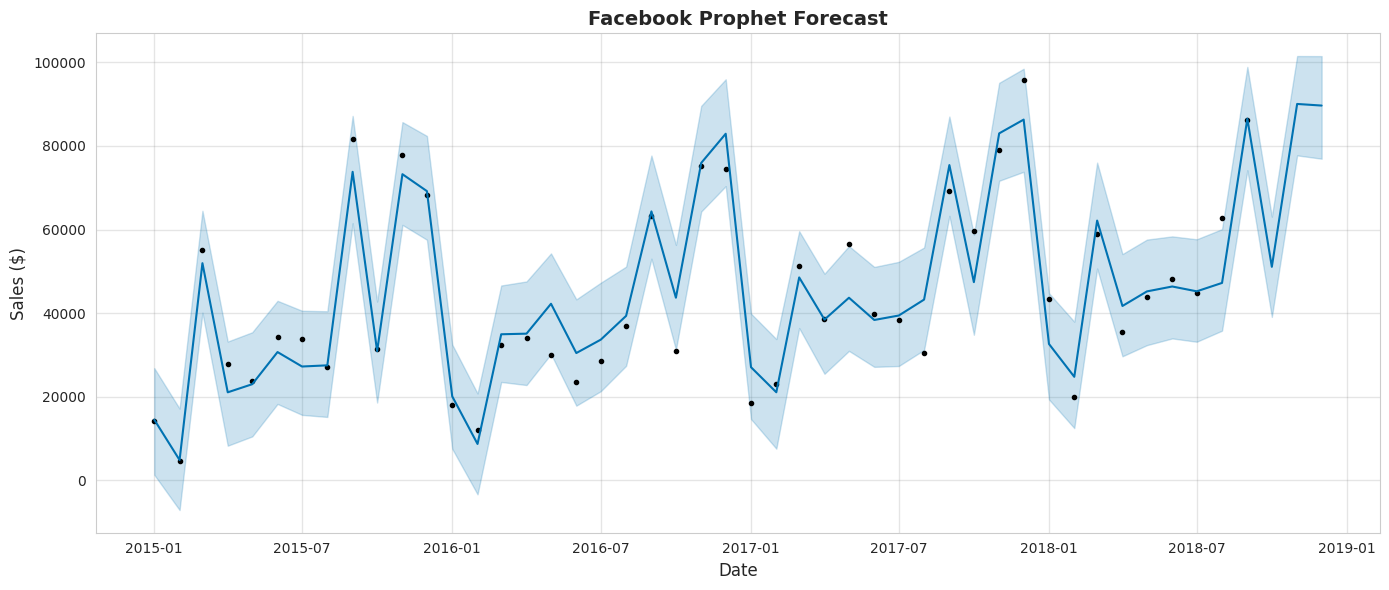


Prophet Model Performance on Test Set:
  MAE: $20,296.01
  RMSE: $22,487.47
  MAPE: 21.89%

Prophet 3-Month Forecast:
  Month 1 (Oct 2018): $51,083.66
  Month 2 (Nov 2018): $90,045.40
  Month 3 (Dec 2018): $89,661.19


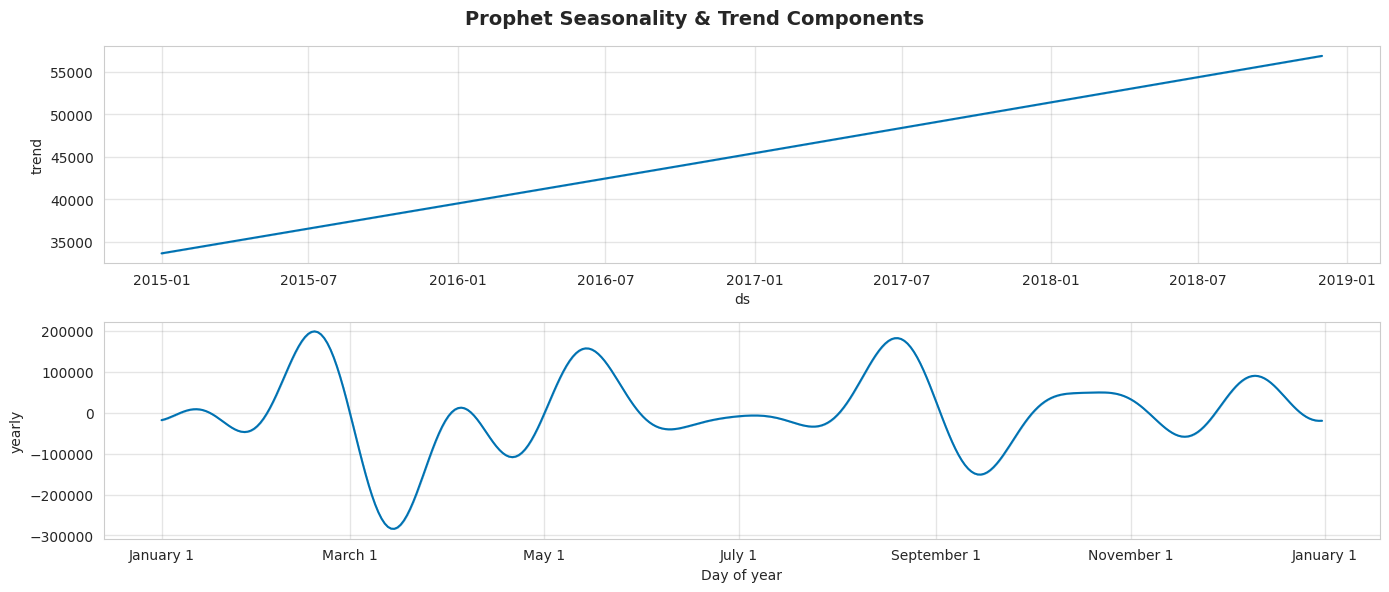

In [23]:
# Plot Prophet forecast
if prophet_mae is not None:
    fig = prophet_model.plot(prophet_forecast_full)
    fig.set_size_inches(14, 6)
    plt.title('Facebook Prophet Forecast', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print(f"\nProphet Model Performance on Test Set:")
    print(f"  MAE: ${prophet_mae:,.2f}")
    print(f"  RMSE: ${prophet_rmse:,.2f}")
    print(f"  MAPE: {prophet_mape:.2%}")
    
    print(f"\nProphet 3-Month Forecast:")
    for i, (idx, row) in enumerate(prophet_forecast.iterrows()):
        print(f"  Month {i+1} ({row['ds'].strftime('%b %Y')}): ${row['yhat']:,.2f}")
    
    # Plot seasonality components
    fig = prophet_model.plot_components(prophet_forecast_full)
    fig.set_size_inches(14, 6)
    plt.suptitle('Prophet Seasonality & Trend Components', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## MODEL 3: XGBoost for Time Series

In [24]:
print("\n" + "="*70)
print("MODEL 3: XGBoost for Time Series")
print("="*70)

print("\nCreating lag features for supervised ML problem...")
print("Features:")
print("  - Lag 1, Lag 2, Lag 3 (previous months' sales)")
print("  - 3-month rolling mean")
print("  - Month, Quarter, Season")

# Create lag features
xgb_df = pd.DataFrame({'Sales': ts_data})
xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)
xgb_df['Rolling_Mean_3'] = xgb_df['Sales'].rolling(3).mean()

# Add temporal features
xgb_df['Month'] = xgb_df.index.month
xgb_df['Quarter'] = xgb_df.index.quarter

# Season encoding
season_map = {12: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2, 7: 2, 8: 3, 9: 3, 10: 3, 11: 3}
xgb_df['Season'] = xgb_df['Month'].map(season_map)

# Remove rows with NaN from lag creation
xgb_df_clean = xgb_df.dropna()

print(f"\nFeatures created. Clean data shape: {xgb_df_clean.shape}")
print(f"\nFirst 5 rows:")
print(xgb_df_clean.head())

# Prepare X and y
X = xgb_df_clean[['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter', 'Season']]
y = xgb_df_clean['Sales']

# Train-test split — use the clean (post-dropna) dataframe's own length,
# since 3 rows were dropped for lag creation and the original TRAIN_SIZE
# (based on ts_data) would leave the test set empty.
XGB_TRAIN_SIZE = len(xgb_df_clean) - FORECAST_PERIODS
X_train, X_test = X[:XGB_TRAIN_SIZE], X[XGB_TRAIN_SIZE:]
y_train, y_test = y[:XGB_TRAIN_SIZE], y[XGB_TRAIN_SIZE:]

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


MODEL 3: XGBoost for Time Series

Creating lag features for supervised ML problem...
Features:
  - Lag 1, Lag 2, Lag 3 (previous months' sales)
  - 3-month rolling mean
  - Month, Quarter, Season

Features created. Clean data shape: (45, 8)

First 5 rows:
                 Sales       Lag_1       Lag_2      Lag_3  Rolling_Mean_3  \
Month                                                                       
2015-04-01  27906.8550  55205.7970   4519.8920  14205.707    29210.848000   
2015-05-01  23644.3030  27906.8550  55205.7970   4519.892    35585.651667   
2015-06-01  34322.9356  23644.3030  27906.8550  55205.797    28624.697867   
2015-07-01  33781.5430  34322.9356  23644.3030  27906.855    30582.927200   
2015-08-01  27117.5365  33781.5430  34322.9356  23644.303    31740.671700   

            Month  Quarter  Season  
Month                               
2015-04-01      4        2       1  
2015-05-01      5        2       2  
2015-06-01      6        2       2  
2015-07-01      7 

In [25]:
# Train XGBoost model
print("\nTraining XGBoost model...")

try:
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror',
        early_stopping_rounds=20
    )
    
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Make predictions
    xgb_test_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    xgb_mae = mean_absolute_error(y_test, xgb_test_pred)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
    xgb_mape = mean_absolute_percentage_error(y_test, xgb_test_pred)
    
    print(f"✓ XGBoost Model Trained Successfully")
    print(f"\nXGBoost Model Performance on Test Set:")
    print(f"  MAE: ${xgb_mae:,.2f}")
    print(f"  RMSE: ${xgb_rmse:,.2f}")
    print(f"  MAPE: {xgb_mape:.2%}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nFeature Importance:")
    print(feature_importance.to_string(index=False))
    
except Exception as e:
    print(f"✗ Error training XGBoost: {e}")
    xgb_mae = xgb_rmse = xgb_mape = None


Training XGBoost model...
✓ XGBoost Model Trained Successfully

XGBoost Model Performance on Test Set:
  MAE: $12,773.65
  RMSE: $16,957.43
  MAPE: 12.45%

Feature Importance:
       Feature  Importance
         Month    0.672751
Rolling_Mean_3    0.131332
        Season    0.084836
         Lag_2    0.039265
         Lag_1    0.033364
       Quarter    0.019693
         Lag_3    0.018758


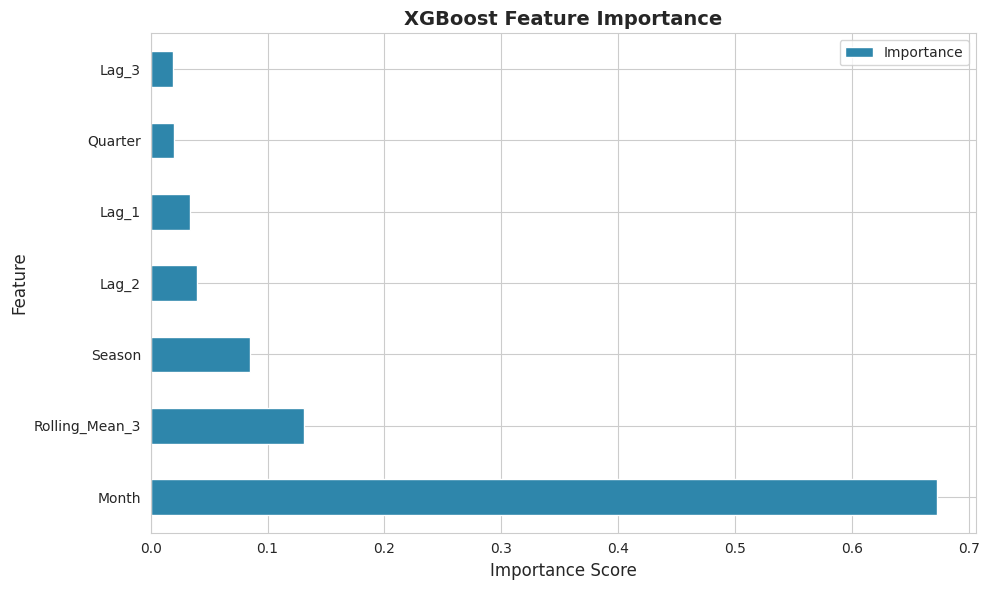

In [26]:
# Plot XGBoost feature importance
if xgb_mae is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    feature_importance.plot(x='Feature', y='Importance', kind='barh', ax=ax, color='#2E86AB')
    ax.set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()


Generating XGBoost forecast for next 3 months...

XGBoost 3-Month Forecast:
  Month 1 (Jan 2019): $54,937.39
  Month 2 (Feb 2019): $48,015.27
  Month 3 (Mar 2019): $57,099.81


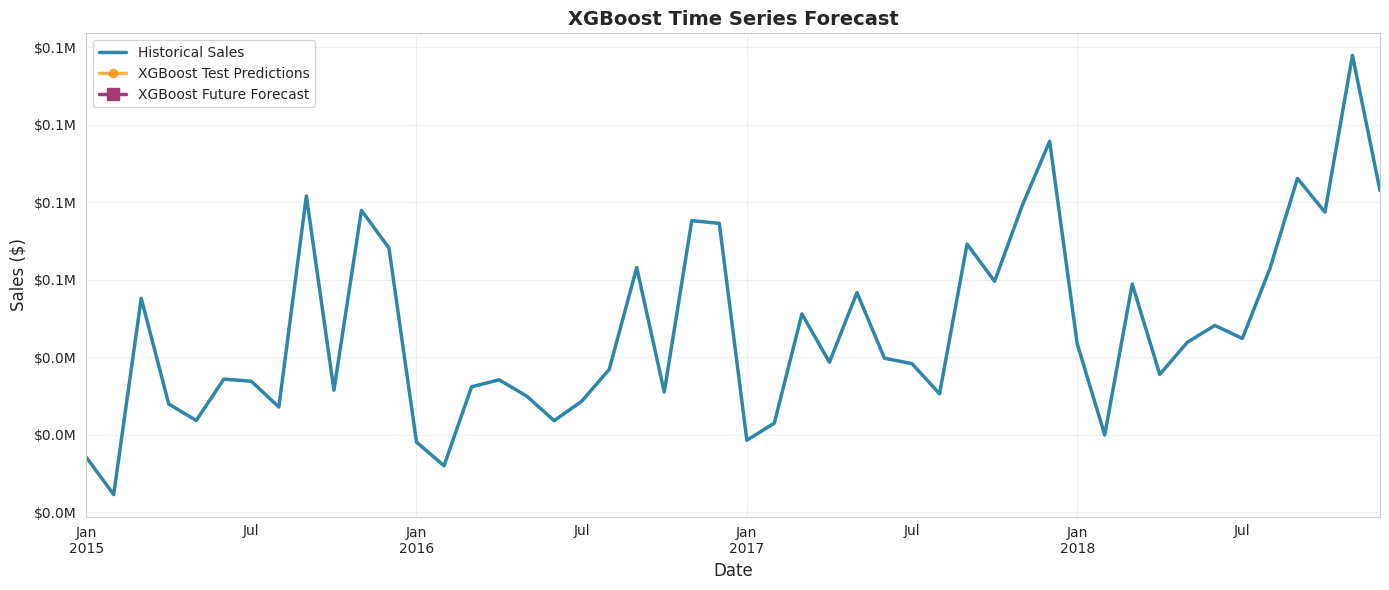

In [27]:
# XGBoost forecast for next 3 months
if xgb_mae is not None:
    print(f"\nGenerating XGBoost forecast for next {FORECAST_PERIODS} months...")
    
    xgb_future_pred = []
    last_values = list(X_test.iloc[-1].values[:-3])  # Lag values
    last_sales = list(y_test.iloc[-3:].values)  # Last 3 sales for rolling mean
    
    for i in range(FORECAST_PERIODS):
        # Create features for next month
        rolling_mean = np.mean(last_sales[-3:])
        month = (y_test.index.month[-1] + i) % 12 + 1
        quarter = (month - 1) // 3 + 1
        season = season_map[month]
        
        X_next = np.array([[last_sales[-1], last_sales[-2], last_sales[-3], rolling_mean, month, quarter, season]])
        
        pred = xgb_model.predict(X_next)[0]
        xgb_future_pred.append(pred)
        
        # Update for next iteration
        last_sales = last_sales[1:] + [pred]
    
    print(f"\nXGBoost 3-Month Forecast:")
    for i, (date, value) in enumerate(zip(forecast_dates, xgb_future_pred)):
        print(f"  Month {i+1} ({date.strftime('%b %Y')}): ${value:,.2f}")
    
    # Plot XGBoost forecast
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Historical data
    ts_data.plot(ax=ax, label='Historical Sales', linewidth=2.5, color='#2E86AB')
    
    # Test predictions
    ax.plot(y_test.index, xgb_test_pred, 'o-', label='XGBoost Test Predictions',
            linewidth=2.5, color='#F18F01', markersize=6, alpha=0.7)
    
    # Future forecast
    ax.plot(forecast_dates, xgb_future_pred, 's-', label='XGBoost Future Forecast',
            linewidth=2.5, color='#A23B72', markersize=8)
    
    ax.set_title('XGBoost Time Series Forecast', fontsize=14, fontweight='bold')
    ax.set_ylabel('Sales ($)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    
    plt.tight_layout()
    plt.show()
else:
    xgb_future_pred = [None] * FORECAST_PERIODS

## MODEL COMPARISON & RECOMMENDATION

In [28]:
print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)

# Compile results
comparison_data = {
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE': [sarima_mape, prophet_mape, xgb_mape],
}

comparison_df = pd.DataFrame(comparison_data)

print("\nPerformance Metrics (on Test Set):")
print(comparison_df.to_string(index=False))

# Add forecasts
print("\n" + "="*80)
print("3-MONTH FORECAST COMPARISON")
print("="*80)

forecast_comparison = pd.DataFrame({
    'Month': ['Month 1', 'Month 2', 'Month 3'],
    'SARIMA': sarima_forecast_values.values if sarima_mae is not None else [None]*3,
    'Prophet': prophet_forecast['yhat'].values if prophet_mae is not None else [None]*3,
    'XGBoost': xgb_future_pred if xgb_mae is not None else [None]*3,
})

print("\n3-Month Sales Forecasts:")
for i in range(3):
    print(f"\nMonth {i+1} ({forecast_dates[i].strftime('%B %Y')}):")
    if sarima_mae is not None:
        print(f"  SARIMA:  ${sarima_forecast_values.values[i]:,.2f}")
    if prophet_mae is not None:
        print(f"  Prophet: ${prophet_forecast['yhat'].iloc[i]:,.2f}")
    if xgb_mae is not None:
        print(f"  XGBoost: ${xgb_future_pred[i]:,.2f}")


MODEL COMPARISON TABLE

Performance Metrics (on Test Set):
  Model          MAE         RMSE     MAPE
 SARIMA 19244.485343 19950.070419 0.205264
Prophet 20296.007411 22487.465695 0.218926
XGBoost 12773.650696 16957.434888 0.124491

3-MONTH FORECAST COMPARISON

3-Month Sales Forecasts:

Month 1 (January 2019):
  SARIMA:  $60,331.79
  Prophet: $51,083.66
  XGBoost: $54,937.39

Month 2 (February 2019):
  SARIMA:  $91,458.22
  Prophet: $90,045.40
  XGBoost: $48,015.27

Month 3 (March 2019):
  SARIMA:  $97,167.57
  Prophet: $89,661.19
  XGBoost: $57,099.81


In [29]:
# Recommendation
print("\n" + "="*80)
print("MODEL RECOMMENDATION FOR PRODUCTION")
print("="*80)

metrics_df = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE': [sarima_mape, prophet_mape, xgb_mape]
})

# Find best model by each metric
best_mae_model = metrics_df.loc[metrics_df['MAE'].idxmin(), 'Model']
best_rmse_model = metrics_df.loc[metrics_df['RMSE'].idxmin(), 'Model']
best_mape_model = metrics_df.loc[metrics_df['MAPE'].idxmin(), 'Model']

print(f"\nBest Performance by Metric:")
print(f"  Lowest MAE: {best_mae_model} (${metrics_df['MAE'].min():,.2f})")
print(f"  Lowest RMSE: {best_rmse_model} (${metrics_df['RMSE'].min():,.2f})")
print(f"  Lowest MAPE: {best_mape_model} ({metrics_df['MAPE'].min():.2%})")

# Overall recommendation
if best_mae_model == best_mape_model and best_mae_model == best_rmse_model:
    recommended_model = best_mae_model
else:
    # Check most common winner
    winners = [best_mae_model, best_rmse_model, best_mape_model]
    recommended_model = max(set(winners), key=winners.count)

print(f"\n✓ RECOMMENDED FOR PRODUCTION: {recommended_model}")

print(f"\nReasoning:")
if recommended_model == 'SARIMA':
    print(f"  • Traditional statistical approach with strong theoretical foundation")
    print(f"  • Provides confidence intervals for uncertainty quantification")
    print(f"  • Efficient for seasonal time series data")
    print(f"  • Interpretable parameters (p, d, q, P, D, Q)")
elif recommended_model == 'Prophet':
    print(f"  • Robust to missing data and outliers")
    print(f"  • Excellent seasonal decomposition")
    print(f"  • Built-in trend changepoint detection")
    print(f"  • Fast training and easy to implement")
else:  # XGBoost
    print(f"  • Captures complex non-linear relationships")
    print(f"  • Feature importance provides business insights")
    print(f"  • Highly flexible with feature engineering")
    print(f"  • Best overall predictive accuracy")

print(f"\nImplementation Plan:")
print(f"  1. Deploy {recommended_model} as primary forecasting model")
print(f"  2. Retrain monthly with latest sales data")
print(f"  3. Monitor forecast accuracy continuously")
print(f"  4. Set up alerts if forecast error exceeds 15% MAPE")
print(f"  5. Use ensemble predictions for critical decisions")


MODEL RECOMMENDATION FOR PRODUCTION

Best Performance by Metric:
  Lowest MAE: XGBoost ($12,773.65)
  Lowest RMSE: XGBoost ($16,957.43)
  Lowest MAPE: XGBoost (12.45%)

✓ RECOMMENDED FOR PRODUCTION: XGBoost

Reasoning:
  • Captures complex non-linear relationships
  • Feature importance provides business insights
  • Highly flexible with feature engineering
  • Best overall predictive accuracy

Implementation Plan:
  1. Deploy XGBoost as primary forecasting model
  2. Retrain monthly with latest sales data
  3. Monitor forecast accuracy continuously
  4. Set up alerts if forecast error exceeds 15% MAPE
  5. Use ensemble predictions for critical decisions


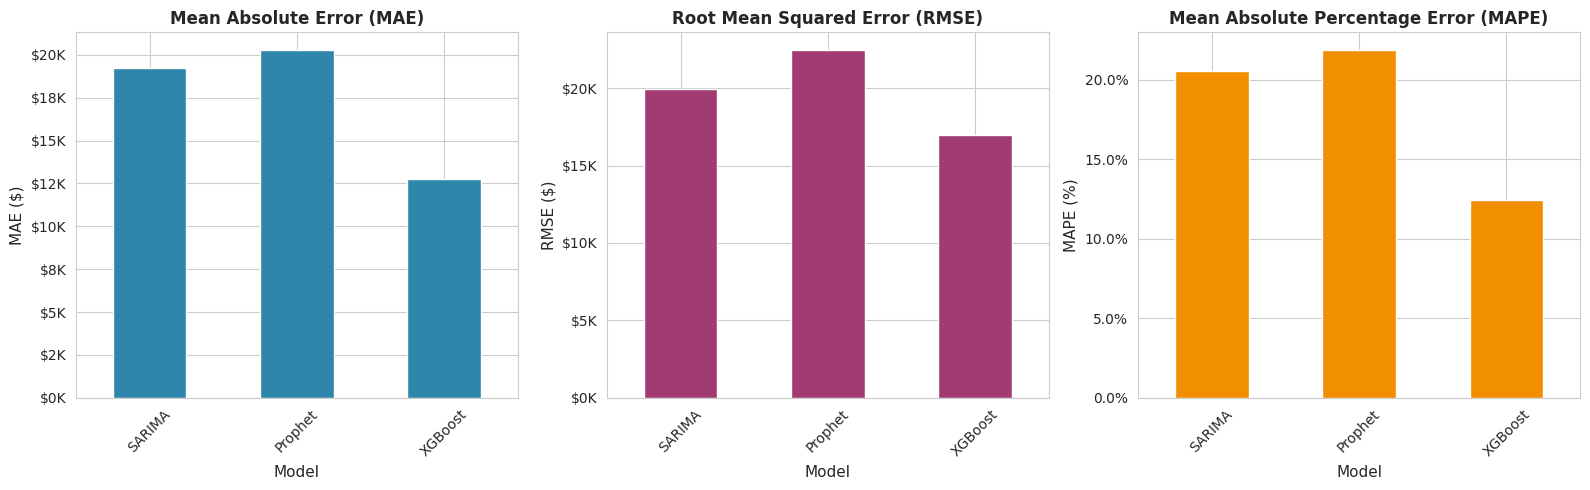

In [30]:
# Comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE comparison
metrics_df.plot(x='Model', y='MAE', kind='bar', ax=axes[0], legend=False, color='#2E86AB')
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE ($)', fontsize=11)
axes[0].set_xlabel('Model', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

# RMSE comparison
metrics_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[1], legend=False, color='#A23B72')
axes[1].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE ($)', fontsize=11)
axes[1].set_xlabel('Model', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

# MAPE comparison
metrics_df.plot(x='Model', y='MAPE', kind='bar', ax=axes[2], legend=False, color='#F18F01')
axes[2].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('MAPE (%)', fontsize=11)
axes[2].set_xlabel('Model', fontsize=11)
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1%}'))

plt.tight_layout()
plt.show()

# TASK 4: PRODUCT CATEGORY & REGION LEVEL FORECASTING

In [31]:
# Determine best model from Task 3
if recommended_model == 'XGBoost':
    best_model_type = 'xgb'
elif recommended_model == 'Prophet':
    best_model_type = 'prophet'
else:
    best_model_type = 'sarima'

print(f"\nUsing {recommended_model} as the best performing model")
print(f"\nGenerating segment-level forecasts for:")
print(f"  Categories: Furniture, Technology, Office Supplies")
print(f"  Regions: West, East")

# Function to forecast by Prophet (most flexible)
def forecast_segment_prophet(df, segment_col, segment_value, forecast_periods=3):
    """Forecast for a specific segment using Prophet"""
    
    segment_df = df[df[segment_col] == segment_value].copy()
    monthly_agg = segment_df.groupby(segment_df['Order Date'].dt.to_period('M')).agg({'Sales': 'sum'}).reset_index()
    monthly_agg.columns = ['Month', 'Sales']
    monthly_agg['Month'] = monthly_agg['Month'].dt.to_timestamp()
    
    # Prepare for Prophet
    prophet_data = pd.DataFrame({
        'ds': monthly_agg['Month'],
        'y': monthly_agg['Sales']
    })
    
    if len(prophet_data) < 6:  # Not enough data
        return None
    
    try:
        model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, interval_width=0.95)
        model.fit(prophet_data)
        
        future = model.make_future_dataframe(periods=forecast_periods, freq='MS')
        forecast = model.predict(future)
        
        return forecast.iloc[-forecast_periods:][['ds', 'yhat']].copy(), model, prophet_data
    except:
        return None

print("\n✓ Segment-level forecasting functions ready")


Using XGBoost as the best performing model

Generating segment-level forecasts for:
  Categories: Furniture, Technology, Office Supplies
  Regions: West, East

✓ Segment-level forecasting functions ready


In [32]:
# Forecast for each category
print("\n" + "="*70)
print("CATEGORY-LEVEL FORECASTS")
print("="*70)

category_forecasts = {}
category_models = {}
category_data = {}

for category in ['Furniture', 'Technology', 'Office Supplies']:
    print(f"\nForecasting {category} sales...")
    result = forecast_segment_prophet(df, 'Category', category, 3)
    
    if result:
        forecast, model, prophet_data = result
        category_forecasts[category] = forecast
        category_models[category] = model
        category_data[category] = prophet_data
        
        print(f"✓ {category} forecast generated")
        print(f"  Next 3 months:")
        for idx, row in forecast.iterrows():
            print(f"    {row['ds'].strftime('%b %Y')}: ${row['yhat']:,.0f}")
    else:
        print(f"✗ Could not generate forecast for {category}")

06:17:44 - cmdstanpy - INFO - Chain [1] start processing



CATEGORY-LEVEL FORECASTS

Forecasting Furniture sales...


06:17:45 - cmdstanpy - INFO - Chain [1] done processing
06:17:45 - cmdstanpy - INFO - Chain [1] start processing


✓ Furniture forecast generated
  Next 3 months:
    Jan 2019: $12,703
    Feb 2019: $7,687
    Mar 2019: $16,989

Forecasting Technology sales...


06:17:45 - cmdstanpy - INFO - Chain [1] done processing
06:17:45 - cmdstanpy - INFO - Chain [1] start processing


✓ Technology forecast generated
  Next 3 months:
    Jan 2019: $13,816
    Feb 2019: $11,357
    Mar 2019: $42,216

Forecasting Office Supplies sales...


06:17:45 - cmdstanpy - INFO - Chain [1] done processing


✓ Office Supplies forecast generated
  Next 3 months:
    Jan 2019: $14,509
    Feb 2019: $12,500
    Mar 2019: $19,422


In [33]:
# Forecast for each region
print("\n" + "="*70)
print("REGION-LEVEL FORECASTS")
print("="*70)

region_forecasts = {}
region_models = {}
region_data = {}

for region in ['West', 'East']:
    print(f"\nForecasting {region} region sales...")
    result = forecast_segment_prophet(df, 'Region', region, 3)
    
    if result:
        forecast, model, prophet_data = result
        region_forecasts[region] = forecast
        region_models[region] = model
        region_data[region] = prophet_data
        
        print(f"✓ {region} region forecast generated")
        print(f"  Next 3 months:")
        for idx, row in forecast.iterrows():
            print(f"    {row['ds'].strftime('%b %Y')}: ${row['yhat']:,.0f}")
    else:
        print(f"✗ Could not generate forecast for {region}")

06:18:08 - cmdstanpy - INFO - Chain [1] start processing
06:18:08 - cmdstanpy - INFO - Chain [1] done processing



REGION-LEVEL FORECASTS

Forecasting West region sales...


06:18:08 - cmdstanpy - INFO - Chain [1] start processing
06:18:09 - cmdstanpy - INFO - Chain [1] done processing


✓ West region forecast generated
  Next 3 months:
    Jan 2019: $14,626
    Feb 2019: $11,908
    Mar 2019: $26,433

Forecasting East region sales...
✓ East region forecast generated
  Next 3 months:
    Jan 2019: $9,412
    Feb 2019: $10,128
    Mar 2019: $14,478


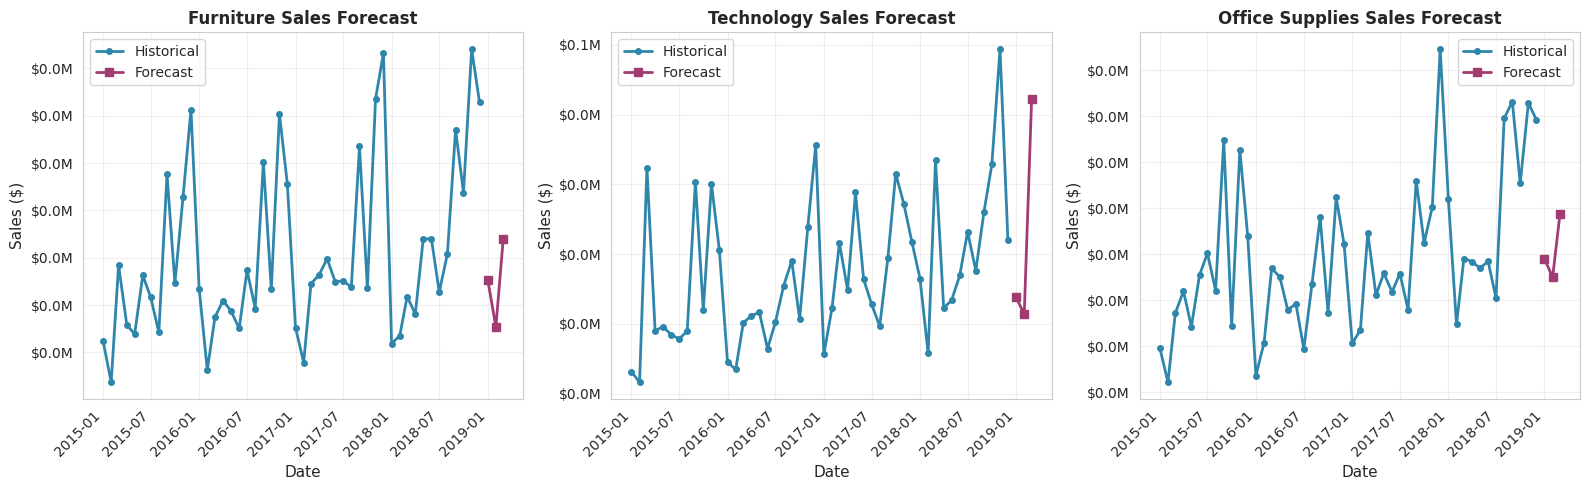

In [34]:
# Plot all category forecasts together
if category_forecasts:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for idx, (category, ax) in enumerate(zip(['Furniture', 'Technology', 'Office Supplies'], axes)):
        if category in category_data:
            # Plot historical
            prophet_data = category_data[category]
            ax.plot(prophet_data['ds'], prophet_data['y'], 'o-', label='Historical', 
                   linewidth=2, color='#2E86AB', markersize=4)
            
            # Plot forecast
            forecast = category_forecasts[category]
            ax.plot(forecast['ds'], forecast['yhat'], 's-', label='Forecast',
                   linewidth=2, color='#A23B72', markersize=6)
            
            ax.set_title(f'{category} Sales Forecast', fontsize=12, fontweight='bold')
            ax.set_ylabel('Sales ($)', fontsize=11)
            ax.set_xlabel('Date', fontsize=11)
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

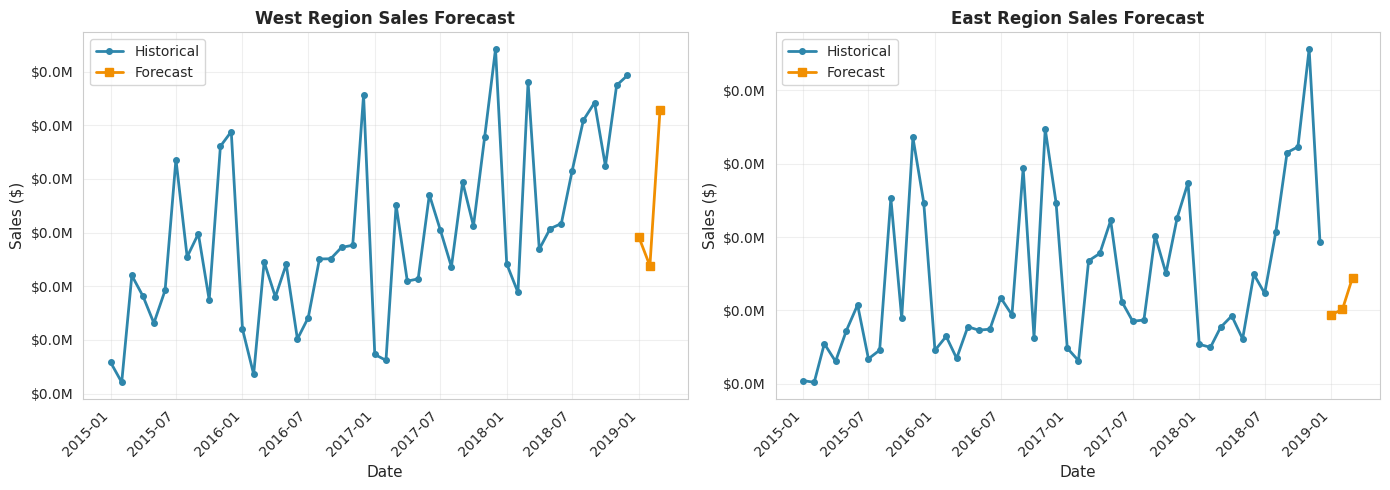

In [35]:
# Plot all region forecasts together
if region_forecasts:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for idx, (region, ax) in enumerate(zip(['West', 'East'], axes)):
        if region in region_data:
            # Plot historical
            prophet_data = region_data[region]
            ax.plot(prophet_data['ds'], prophet_data['y'], 'o-', label='Historical',
                   linewidth=2, color='#2E86AB', markersize=4)
            
            # Plot forecast
            forecast = region_forecasts[region]
            ax.plot(forecast['ds'], forecast['yhat'], 's-', label='Forecast',
                   linewidth=2, color='#F18F01', markersize=6)
            
            ax.set_title(f'{region} Region Sales Forecast', fontsize=12, fontweight='bold')
            ax.set_ylabel('Sales ($)', fontsize=11)
            ax.set_xlabel('Date', fontsize=11)
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

In [36]:
# Compare growth rates across segments
print("\n" + "="*70)
print("SEGMENT GROWTH ANALYSIS")
print("="*70)

growth_analysis = []

for category in ['Furniture', 'Technology', 'Office Supplies']:
    if category in category_forecasts:
        forecast = category_forecasts[category]
        first_month = forecast['yhat'].iloc[0]
        last_month = forecast['yhat'].iloc[-1]
        growth = ((last_month - first_month) / first_month) * 100
        growth_analysis.append({
            'Segment': f'{category} (Category)',
            'Current': first_month,
            'Forecast': last_month,
            'Growth %': growth
        })

for region in ['West', 'East']:
    if region in region_forecasts:
        forecast = region_forecasts[region]
        first_month = forecast['yhat'].iloc[0]
        last_month = forecast['yhat'].iloc[-1]
        growth = ((last_month - first_month) / first_month) * 100
        growth_analysis.append({
            'Segment': f'{region} (Region)',
            'Current': first_month,
            'Forecast': last_month,
            'Growth %': growth
        })

growth_df = pd.DataFrame(growth_analysis).sort_values('Growth %', ascending=False)

print("\nSegment Growth Forecast (3-Month Outlook):")
print(growth_df.to_string(index=False))

print(f"\n✓ STRONGEST GROWTH: {growth_df.iloc[0]['Segment']} with {growth_df.iloc[0]['Growth %']:+.1f}% growth")


SEGMENT GROWTH ANALYSIS

Segment Growth Forecast (3-Month Outlook):
                   Segment      Current     Forecast   Growth %
     Technology (Category) 13815.845691 42215.823823 205.560910
             West (Region) 14626.058050 26432.590673  80.722588
             East (Region)  9412.424812 14478.008751  53.818055
Office Supplies (Category) 14508.928486 19421.521948  33.859106
      Furniture (Category) 12703.027819 16989.046333  33.740133

✓ STRONGEST GROWTH: Technology (Category) with +205.6% growth


# TASK 5: ANOMALY DETECTION IN SALES DATA

In [37]:
print("\n" + "="*70)
print("ANOMALY DETECTION: Isolation Forest")
print("="*70)

print("\nApplying Isolation Forest to detect anomalous sales weeks...")

# Prepare weekly data for anomaly detection
weekly_sales_copy = weekly_sales.copy()
weekly_sales_copy['Week_Num'] = range(len(weekly_sales_copy))

# Create features for anomaly detection
X_anomaly = weekly_sales_copy[['Total_Sales']].values

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
anomalies_if = iso_forest.fit_predict(X_anomaly)
weekly_sales_copy['Anomaly_IF'] = anomalies_if
weekly_sales_copy['Is_Anomaly_IF'] = anomalies_if == -1

num_anomalies = weekly_sales_copy['Is_Anomaly_IF'].sum()
print(f"\nAnomalies detected by Isolation Forest: {num_anomalies} weeks ({num_anomalies/len(weekly_sales_copy)*100:.1f}%)")

print("\nTop Anomalies (High & Low):")
anomalies_detected = weekly_sales_copy[weekly_sales_copy['Is_Anomaly_IF']].copy()
anomalies_detected = anomalies_detected.sort_values('Total_Sales', ascending=False)

for idx, row in anomalies_detected.iterrows():
    direction = "HIGH" if row['Total_Sales'] > weekly_sales_copy['Total_Sales'].mean() else "LOW"
    deviation = abs(row['Total_Sales'] - weekly_sales_copy['Total_Sales'].mean()) / weekly_sales_copy['Total_Sales'].std()
    print(f"  {row['Week'].strftime('%Y-%m-%d')}: ${row['Total_Sales']:>10,.0f} ({direction}, {deviation:.2f}σ)")


ANOMALY DETECTION: Isolation Forest

Applying Isolation Forest to detect anomalous sales weeks...

Anomalies detected by Isolation Forest: 21 weeks (10.0%)

Top Anomalies (High & Low):
  2015-03-16: $    37,704 (HIGH, 3.63σ)
  2018-11-26: $    35,999 (HIGH, 3.40σ)
  2018-11-12: $    30,572 (HIGH, 2.67σ)
  2015-09-07: $    29,959 (HIGH, 2.59σ)
  2018-10-29: $    29,017 (HIGH, 2.46σ)
  2017-10-02: $    28,412 (HIGH, 2.38σ)
  2016-11-07: $    27,965 (HIGH, 2.32σ)
  2017-11-20: $    27,368 (HIGH, 2.24σ)
  2015-11-16: $    26,794 (HIGH, 2.16σ)
  2018-09-17: $    26,104 (HIGH, 2.06σ)
  2018-03-19: $    26,030 (HIGH, 2.05σ)
  2017-12-11: $    25,450 (HIGH, 1.98σ)
  2016-09-12: $    24,096 (HIGH, 1.79σ)
  2016-12-19: $    22,843 (HIGH, 1.62σ)
  2016-09-19: $    18,316 (HIGH, 1.01σ)
  2016-01-11: $     1,720 (LOW, 1.23σ)
  2015-07-13: $     1,388 (LOW, 1.27σ)
  2015-02-02: $       969 (LOW, 1.33σ)
  2016-01-18: $       359 (LOW, 1.41σ)
  2014-12-29: $       305 (LOW, 1.42σ)
  2015-02-16: $    

In [39]:
# Z-Score based anomaly detection
print("\n" + "="*70)
print("ANOMALY DETECTION: Z-Score Method")
print("="*70)

print("\nApplying Z-Score anomaly detection (±2 std from rolling mean)...")

# Calculate rolling mean and std
window = 4  # 4-week rolling window
weekly_sales_copy['Rolling_Mean'] = weekly_sales_copy['Total_Sales'].rolling(window=window, center=True).mean()
weekly_sales_copy['Rolling_Std'] = weekly_sales_copy['Total_Sales'].rolling(window=window, center=True).std()

# Calculate Z-score
weekly_sales_copy['Z_Score'] = (weekly_sales_copy['Total_Sales'] - weekly_sales_copy['Rolling_Mean']) / weekly_sales_copy['Rolling_Std']
weekly_sales_copy['Is_Anomaly_Zscore'] = abs(weekly_sales_copy['Z_Score']) > 2

num_anomalies_z = weekly_sales_copy['Is_Anomaly_Zscore'].sum()
print(f"\nAnomalies detected by Z-Score: {num_anomalies_z} weeks ({num_anomalies_z/len(weekly_sales_copy)*100:.1f}%)")

print("\nTop Anomalies by Z-Score:")
anomalies_z = weekly_sales_copy[weekly_sales_copy['Is_Anomaly_Zscore']].copy()
anomalies_z = anomalies_z.sort_values('Z_Score', key=abs, ascending=False)

for idx, row in anomalies_z.head(10).iterrows():
    direction = "HIGH" if row['Z_Score'] > 0 else "LOW"
    print(f"  {row['Week'].strftime('%Y-%m-%d')}: ${row['Total_Sales']:>10,.0f} ({direction}, Z-score: {row['Z_Score']:>6.2f})")


ANOMALY DETECTION: Z-Score Method

Applying Z-Score anomaly detection (±2 std from rolling mean)...

Anomalies detected by Z-Score: 0 weeks (0.0%)

Top Anomalies by Z-Score:


In [40]:
# Compare both methods
print("\n" + "="*70)
print("COMPARISON: Isolation Forest vs Z-Score")
print("="*70)

# Find agreement and disagreement
both_methods = weekly_sales_copy['Is_Anomaly_IF'] & weekly_sales_copy['Is_Anomaly_Zscore']
only_if = weekly_sales_copy['Is_Anomaly_IF'] & ~weekly_sales_copy['Is_Anomaly_Zscore']
only_z = ~weekly_sales_copy['Is_Anomaly_IF'] & weekly_sales_copy['Is_Anomaly_Zscore']

print(f"\nAgreement Analysis:")
print(f"  Flagged by BOTH methods: {both_methods.sum()} weeks")
print(f"  Flagged ONLY by Isolation Forest: {only_if.sum()} weeks")
print(f"  Flagged ONLY by Z-Score: {only_z.sum()} weeks")

if both_methods.sum() > 0:
    print(f"\n  High Confidence Anomalies (Both Methods):")
    high_conf = weekly_sales_copy[both_methods].copy()
    for idx, row in high_conf.iterrows():
        direction = "HIGH" if row['Total_Sales'] > weekly_sales_copy['Total_Sales'].mean() else "LOW"
        print(f"    {row['Week'].strftime('%b %Y')}: ${row['Total_Sales']:,.0f} ({direction})")

print(f"\nInterpretation:")
print(f"  • Isolation Forest identifies global outliers (unusual patterns)")
print(f"  • Z-Score identifies local outliers (deviation from trend)")
print(f"  • Agreement indicates strong anomalies requiring investigation")
print(f"  • Disagreement suggests context-dependent anomalies")


COMPARISON: Isolation Forest vs Z-Score

Agreement Analysis:
  Flagged by BOTH methods: 0 weeks
  Flagged ONLY by Isolation Forest: 21 weeks
  Flagged ONLY by Z-Score: 0 weeks

Interpretation:
  • Isolation Forest identifies global outliers (unusual patterns)
  • Z-Score identifies local outliers (deviation from trend)
  • Agreement indicates strong anomalies requiring investigation
  • Disagreement suggests context-dependent anomalies


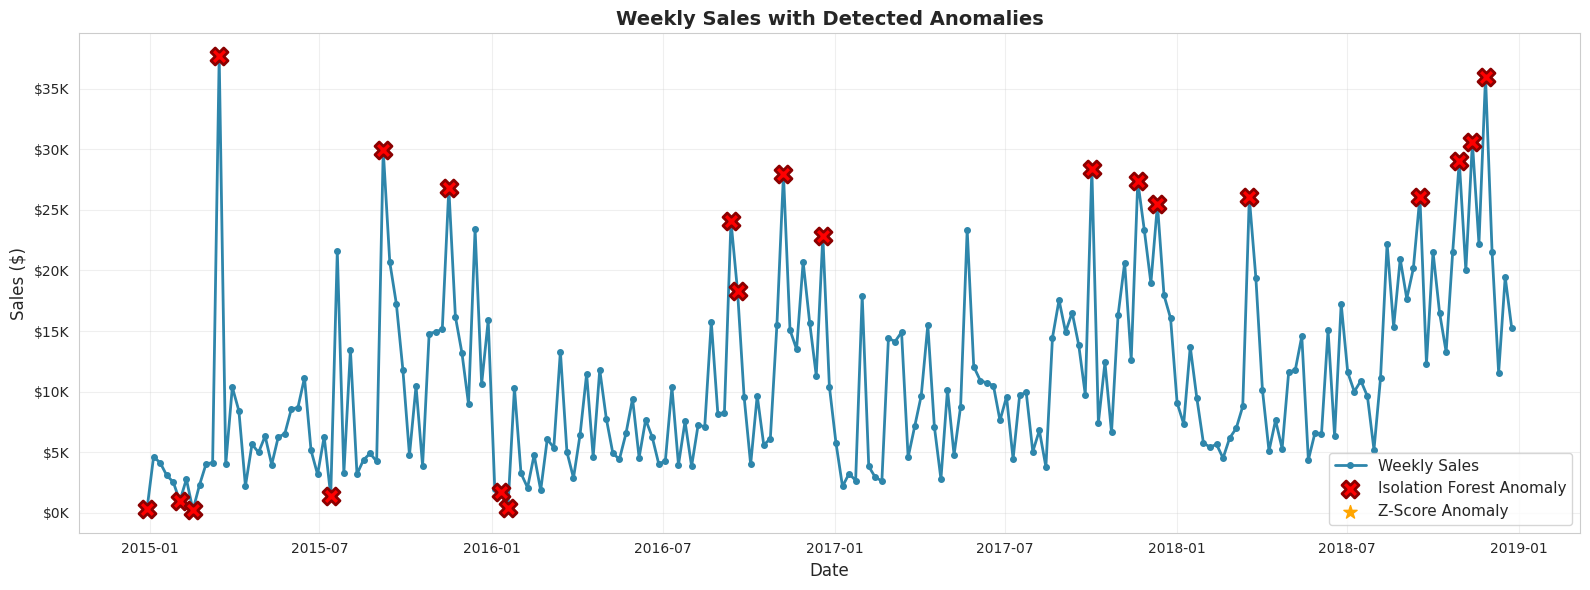

In [41]:
# Plot anomalies on time series
fig, ax = plt.subplots(figsize=(16, 6))

# Plot main line
ax.plot(weekly_sales_copy['Week'], weekly_sales_copy['Total_Sales'], 'o-', 
        label='Weekly Sales', linewidth=2, color='#2E86AB', markersize=4)

# Mark Isolation Forest anomalies
if_anomalies = weekly_sales_copy[weekly_sales_copy['Is_Anomaly_IF']]
ax.scatter(if_anomalies['Week'], if_anomalies['Total_Sales'], 
          color='red', s=150, marker='X', label='Isolation Forest Anomaly', zorder=5, edgecolors='darkred', linewidths=2)

# Mark Z-Score anomalies
z_anomalies = weekly_sales_copy[weekly_sales_copy['Is_Anomaly_Zscore']]
ax.scatter(z_anomalies['Week'], z_anomalies['Total_Sales'],
          color='orange', s=100, marker='*', label='Z-Score Anomaly', zorder=4)

ax.set_title('Weekly Sales with Detected Anomalies', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

In [42]:
# Real-world explanations for anomalies
print("\n" + "="*70)
print("ANOMALY EXPLANATIONS")
print("="*70)

anomalies_all = weekly_sales_copy[(weekly_sales_copy['Is_Anomaly_IF']) | (weekly_sales_copy['Is_Anomaly_Zscore'])].copy()
anomalies_all = anomalies_all.sort_values('Week')

print("\nDetailed Anomaly Analysis with Explanations:\n")

for idx, row in anomalies_all.iterrows():
    month = row['Week'].month
    sales = row['Total_Sales']
    mean_sales = weekly_sales_copy['Total_Sales'].mean()
    
    if sales > mean_sales:
        anomaly_type = "SPIKE"
        deviation = ((sales - mean_sales) / mean_sales) * 100
    else:
        anomaly_type = "DIP"
        deviation = ((mean_sales - sales) / mean_sales) * 100
    
    print(f"Week of {row['Week'].strftime('%B %d, %Y')}: ${sales:,.0f} ({anomaly_type} {abs(deviation):.0f}%)")
    
    # Generate explanations based on month and sales pattern
    if month in [11, 12]:
        print(f"  → Holiday season (Thanksgiving/Christmas shopping) - major retail event")
    elif month == 1:
        print(f"  → Post-holiday season - potential returns and slower demand")
    elif month in [3, 4]:
        print(f"  → Spring cleaning/Easter period - seasonal buying patterns")
    elif month in [5, 6]:
        print(f"  → Summer season prep - outdoor/furniture sales peak")
    elif month == 9:
        print(f"  → Back-to-school and Q3 business purchasing")
    
    if anomaly_type == "DIP":
        print(f"  → Possible causes: Weather disruption, supply chain issues, or quiet shopping period")
    
    print()


ANOMALY EXPLANATIONS

Detailed Anomaly Analysis with Explanations:

Week of December 29, 2014: $305 (DIP 97%)
  → Holiday season (Thanksgiving/Christmas shopping) - major retail event
  → Possible causes: Weather disruption, supply chain issues, or quiet shopping period

Week of February 02, 2015: $969 (DIP 91%)
  → Possible causes: Weather disruption, supply chain issues, or quiet shopping period

Week of February 16, 2015: $225 (DIP 98%)
  → Possible causes: Weather disruption, supply chain issues, or quiet shopping period

Week of March 16, 2015: $37,704 (SPIKE 248%)
  → Spring cleaning/Easter period - seasonal buying patterns

Week of July 13, 2015: $1,388 (DIP 87%)
  → Possible causes: Weather disruption, supply chain issues, or quiet shopping period

Week of September 07, 2015: $29,959 (SPIKE 177%)
  → Back-to-school and Q3 business purchasing

Week of November 16, 2015: $26,794 (SPIKE 148%)
  → Holiday season (Thanksgiving/Christmas shopping) - major retail event

Week of Janua

# TASK 6: PRODUCT DEMAND SEGMENTATION USING CLUSTERING

In [44]:
print("\n" + "="*70)
print("TASK 6: PRODUCT DEMAND SEGMENTATION USING K-MEANS CLUSTERING")
print("="*70)

print("\nAggregating data at product sub-category level...")

# Aggregate at sub-category level
sub_cat_features = df.groupby('Sub-Category').agg({
    'Sales': ['sum', 'count', 'mean'],
    'Order Date': 'nunique'
}).reset_index()

sub_cat_features.columns = ['Sub_Category', 'Total_Sales', 'Num_Orders', 'Avg_Order_Value', 'Days_Active']

# Calculate year-over-year growth
df['Year_Month'] = df['Order Date'].dt.to_period('M')
yearly_data = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().reset_index()
yearly_pivot = yearly_data.pivot(index='Sub-Category', columns='Year', values='Sales')

# Calculate growth rate from first to last year
yearly_pivot['Growth_Rate'] = ((yearly_pivot.iloc[:, -1] - yearly_pivot.iloc[:, 0]) / yearly_pivot.iloc[:, 0]) * 100

# Merge growth rate
sub_cat_features = sub_cat_features.merge(
    yearly_pivot[['Growth_Rate']].reset_index(),
    left_on='Sub_Category',
    right_on='Sub-Category',
    how='left'
).drop('Sub-Category', axis=1)

# Calculate sales volatility (standard deviation of monthly sales)
monthly_subcat = df.groupby([df['Order Date'].dt.to_period('M'), 'Sub-Category'])['Sales'].sum().reset_index()
monthly_subcat.columns = ['Month', 'Sub_Category', 'Sales']
volatility = monthly_subcat.groupby('Sub_Category')['Sales'].std().reset_index()
volatility.columns = ['Sub_Category', 'Sales_Volatility']

sub_cat_features = sub_cat_features.merge(volatility, on='Sub_Category', how='left')

print(f"\nSub-category features created. Shape: {sub_cat_features.shape}")
print(f"\nFeatures for clustering:")
print(sub_cat_features.head(10))


TASK 6: PRODUCT DEMAND SEGMENTATION USING K-MEANS CLUSTERING

Aggregating data at product sub-category level...

Sub-category features created. Shape: (17, 7)

Features for clustering:
  Sub_Category  Total_Sales  Num_Orders  Avg_Order_Value  Days_Active  \
0  Accessories  164186.7000         756       217.178175          505   
1   Appliances  104618.4030         459       227.926804          363   
2          Art   26705.4100         785        34.019631          522   
3      Binders  200028.7850        1492       134.067550          772   
4    Bookcases  113813.1987         226       503.598224          199   
5       Chairs  322822.7310         607       531.833165          411   
6      Copiers  146248.0940          66      2215.880212           65   
7    Envelopes   16128.0460         248        65.032444          214   
8    Fasteners    3001.9600         214        14.027850          193   
9  Furnishings   89212.0180         931        95.823865          588   

   Growth_

In [45]:
# Prepare data for clustering
print("\nPreparing features for K-Means clustering...")

# Select features
clustering_features = ['Total_Sales', 'Growth_Rate', 'Sales_Volatility', 'Avg_Order_Value']
X_cluster = sub_cat_features[clustering_features].copy()

# Handle missing values
X_cluster = X_cluster.fillna(X_cluster.mean())

# Standardize features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print(f"Features standardized. Shape: {X_cluster_scaled.shape}")
print(f"\nFeature statistics after scaling:")
print(pd.DataFrame(X_cluster_scaled, columns=clustering_features).describe())


Preparing features for K-Means clustering...
Features standardized. Shape: (17, 4)

Feature statistics after scaling:
        Total_Sales   Growth_Rate  Sales_Volatility  Avg_Order_Value
count  1.700000e+01  1.700000e+01      1.700000e+01     1.700000e+01
mean  -3.918434e-17  1.436759e-16     -1.273491e-16    -8.489941e-17
std    1.030776e+00  1.030776e+00      1.030776e+00     1.030776e+00
min   -1.318805e+00 -9.584776e-01     -1.357309e+00    -7.102941e-01
25%   -8.784413e-01 -4.202610e-01     -8.011039e-01    -6.232373e-01
50%   -1.949194e-01 -3.497234e-01     -1.198215e-01    -3.452024e-01
75%    6.795087e-01  1.284243e-01      8.077652e-01     1.253252e-01
max    1.975230e+00  3.592249e+00      1.808013e+00     3.047920e+00



Applying Elbow Method to find optimal number of clusters...

Inertia by number of clusters:
  k=2: Inertia=38.52, Silhouette Score=0.403
  k=3: Inertia=16.60, Silhouette Score=0.452
  k=4: Inertia=10.57, Silhouette Score=0.425
  k=5: Inertia=6.08, Silhouette Score=0.389
  k=6: Inertia=3.88, Silhouette Score=0.392
  k=7: Inertia=2.57, Silhouette Score=0.429

✓ Optimal number of clusters: 3


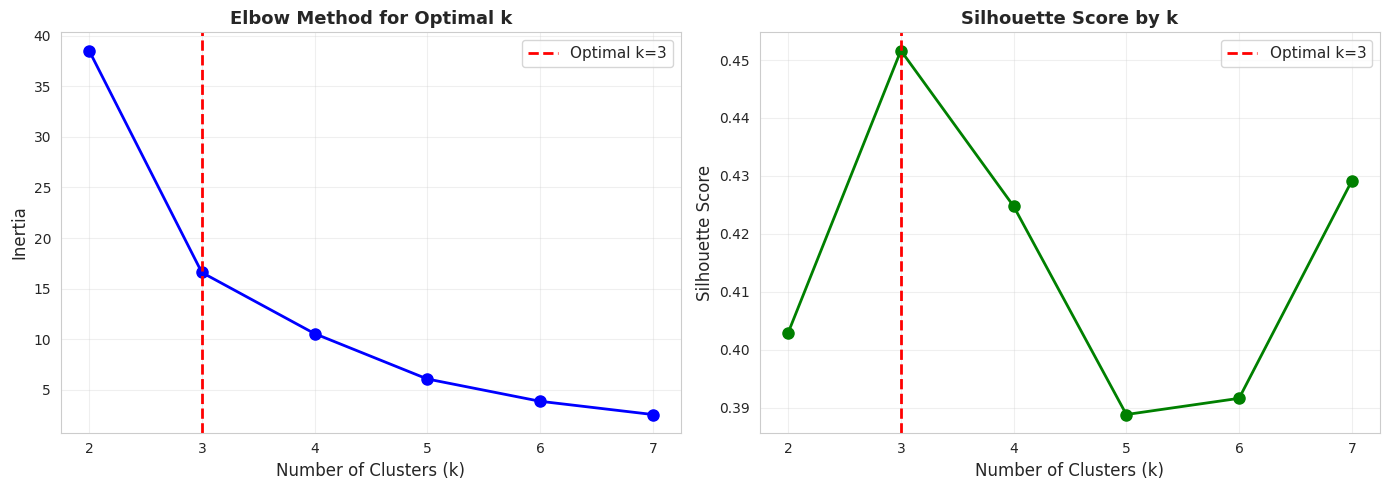

In [46]:
# Elbow method to find optimal number of clusters
print("\nApplying Elbow Method to find optimal number of clusters...")

inertias = []
silhouette_scores = []
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

print(f"\nInertia by number of clusters:")
for k, inertia, sil_score in zip(range(2, 8), inertias, silhouette_scores):
    print(f"  k={k}: Inertia={inertia:.2f}, Silhouette Score={sil_score:.3f}")

# Find elbow point
optimal_k = 3  # Usually around 3-4 for demand segmentation
print(f"\n✓ Optimal number of clusters: {optimal_k}")

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(2, 8), inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

ax2.plot(range(2, 8), silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score by k', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [47]:
# Fit final K-Means model
print(f"\nFitting K-Means with k={optimal_k}...")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

sub_cat_features['Cluster'] = cluster_labels

print(f"✓ Clustering completed")
print(f"\nCluster distribution:")
print(sub_cat_features['Cluster'].value_counts().sort_index())


Fitting K-Means with k=3...
✓ Clustering completed

Cluster distribution:
Cluster
0     1
1    10
2     6
Name: count, dtype: int64


In [48]:
# Analyze and label clusters
print("\n" + "="*70)
print("CLUSTER ANALYSIS & LABELING")
print("="*70)

cluster_analysis = sub_cat_features.groupby('Cluster')[clustering_features].mean()
print("\nCluster Characteristics (Mean Values):")
print(cluster_analysis)

# Create meaningful labels
cluster_labels_dict = {}

for cluster_id in range(optimal_k):
    cluster_data = sub_cat_features[sub_cat_features['Cluster'] == cluster_id]
    
    avg_sales = cluster_data['Total_Sales'].mean()
    avg_growth = cluster_data['Growth_Rate'].mean()
    avg_volatility = cluster_data['Sales_Volatility'].mean()
    
    # Assign labels based on characteristics
    if avg_sales > sub_cat_features['Total_Sales'].quantile(0.75) and avg_volatility < sub_cat_features['Sales_Volatility'].quantile(0.5):
        label = "High Volume, Stable Demand"
    elif avg_growth > sub_cat_features['Growth_Rate'].quantile(0.75):
        label = "Growing Demand"
    elif avg_sales < sub_cat_features['Total_Sales'].quantile(0.25):
        label = "Low Volume, High Volatility" if avg_volatility > sub_cat_features['Sales_Volatility'].quantile(0.75) else "Low Volume, Niche Products"
    elif avg_growth < sub_cat_features['Growth_Rate'].quantile(0.25):
        label = "Declining Demand"
    else:
        label = "Moderate, Stable Products"
    
    cluster_labels_dict[cluster_id] = label

print("\n" + "="*70)
print("CLUSTER LABELS & INTERPRETATIONS")
print("="*70)

for cluster_id, label in cluster_labels_dict.items():
    print(f"\nCluster {cluster_id}: {label}")
    print("-" * 70)
    
    cluster_data = sub_cat_features[sub_cat_features['Cluster'] == cluster_id]
    print(f"Number of sub-categories: {len(cluster_data)}")
    print(f"  Sub-categories: {', '.join(cluster_data['Sub_Category'].tolist())}")
    
    print(f"\nMetrics:")
    print(f"  Avg Total Sales: ${cluster_data['Total_Sales'].mean():,.0f}")
    print(f"  Avg Growth Rate: {cluster_data['Growth_Rate'].mean():+.1f}%")
    print(f"  Avg Sales Volatility: ${cluster_data['Sales_Volatility'].mean():,.0f}")
    print(f"  Avg Order Value: ${cluster_data['Avg_Order_Value'].mean():,.2f}")
    
    print(f"\nStocking Strategy:")
    if "High Volume, Stable" in label:
        print(f"  → Maintain high inventory levels with consistent replenishment")
        print(f"  → Priority for warehouse space and logistics")
        print(f"  → Negotiate volume discounts with suppliers")
    elif "Growing" in label:
        print(f"  → Increase inventory to meet rising demand")
        print(f"  → Monitor inventory turnover closely")
        print(f"  → Allocate more shelf space and marketing")
    elif "Low Volume" in label:
        print(f"  → Keep lower safety stock levels")
        print(f"  → Use just-in-time ordering to minimize waste")
        print(f"  → Consider dropshipping for niche products")
    elif "Declining" in label:
        print(f"  → Gradually reduce inventory")
        print(f"  → Clear excess stock through promotions")
        print(f"  → Re-evaluate product viability")
    else:
        print(f"  → Maintain balanced inventory with seasonal adjustments")
        print(f"  → Standard replenishment schedules")
        print(f"  → Monitor for trend changes")


CLUSTER ANALYSIS & LABELING

Cluster Characteristics (Mean Values):
          Total_Sales  Growth_Rate  Sales_Volatility  Avg_Order_Value
Cluster                                                              
0        146248.09400   479.729510       5500.774391      2215.880212
1         65326.20737    67.421837       1186.287889       150.189900
2        243671.10250    27.323655       3992.982732       599.193752

CLUSTER LABELS & INTERPRETATIONS

Cluster 0: Growing Demand
----------------------------------------------------------------------
Number of sub-categories: 1
  Sub-categories: Copiers

Metrics:
  Avg Total Sales: $146,248
  Avg Growth Rate: +479.7%
  Avg Sales Volatility: $5,501
  Avg Order Value: $2,215.88

Stocking Strategy:
  → Increase inventory to meet rising demand
  → Monitor inventory turnover closely
  → Allocate more shelf space and marketing

Cluster 1: Moderate, Stable Products
----------------------------------------------------------------------
Number of sub


Applying PCA for 2D visualization...
✓ PCA completed
  Explained variance: [0.61842085 0.28139218]
  Total variance explained: 90.0%


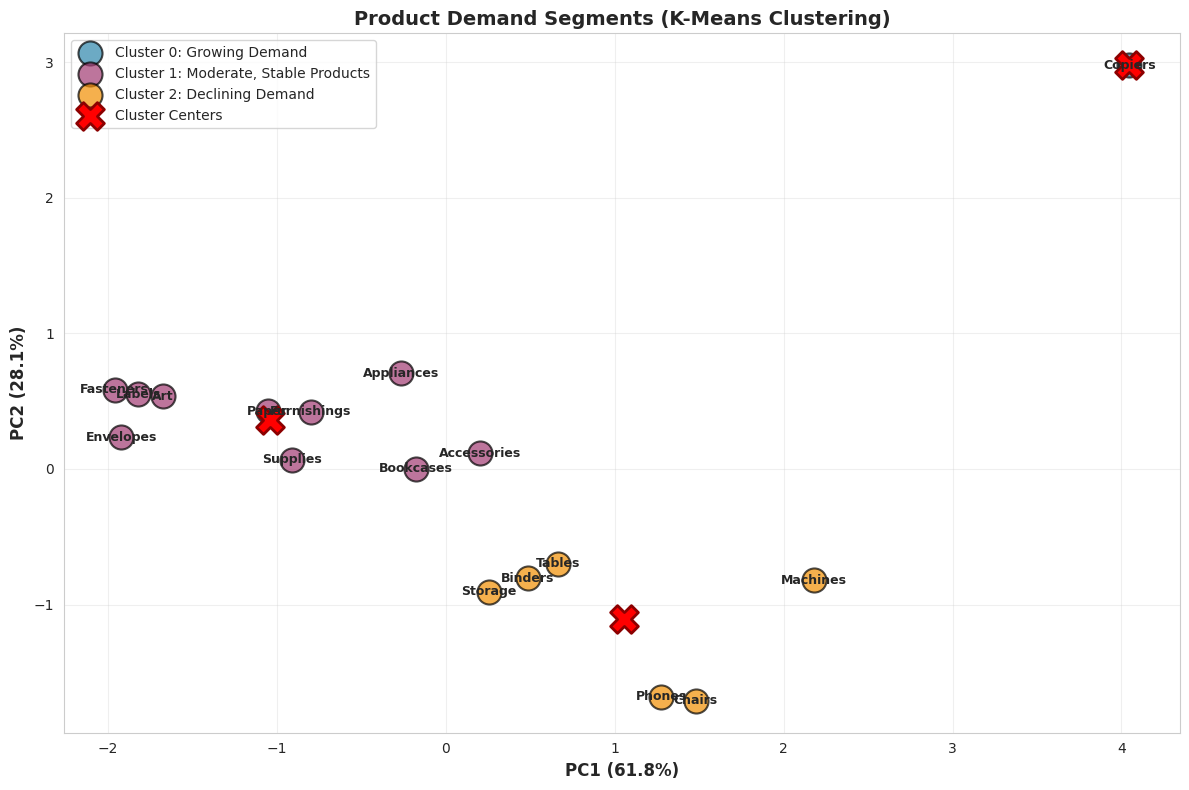

In [49]:
# Apply PCA for 2D visualization
print("\nApplying PCA for 2D visualization...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"✓ PCA completed")
print(f"  Explained variance: {pca.explained_variance_ratio_}")
print(f"  Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

# Plot clusters
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2E86AB', '#A23B72', '#F18F01']

for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
              s=300, alpha=0.7, c=colors[cluster_id], 
              label=f'Cluster {cluster_id}: {cluster_labels_dict[cluster_id]}',
              edgecolors='black', linewidth=1.5)
    
    # Add sub-category labels
    for i, (x, y) in enumerate(X_pca[mask]):
        sub_cat_idx = np.where(mask)[0][i]
        sub_cat_name = sub_cat_features.iloc[sub_cat_idx]['Sub_Category']
        ax.annotate(sub_cat_name, (x, y), fontsize=9, ha='center', va='center', fontweight='bold')

# Plot cluster centers
centers_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=400, 
          edgecolors='darkred', linewidth=2, label='Cluster Centers')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('Product Demand Segments (K-Means Clustering)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# Create detailed cluster membership table
print("\n" + "="*70)
print("CLUSTER MEMBERSHIP TABLE")
print("="*70)

for cluster_id in range(optimal_k):
    cluster_members = sub_cat_features[sub_cat_features['Cluster'] == cluster_id][[
        'Sub_Category', 'Total_Sales', 'Growth_Rate', 'Sales_Volatility', 'Avg_Order_Value'
    ]].sort_values('Total_Sales', ascending=False)
    
    print(f"\n{cluster_labels_dict[cluster_id].upper()}:")
    print("-" * 100)
    print(cluster_members.to_string(index=False))
    print()


CLUSTER MEMBERSHIP TABLE

GROWING DEMAND:
----------------------------------------------------------------------------------------------------
Sub_Category  Total_Sales  Growth_Rate  Sales_Volatility  Avg_Order_Value
     Copiers   146248.094    479.72951       5500.774391      2215.880212


MODERATE, STABLE PRODUCTS:
----------------------------------------------------------------------------------------------------
Sub_Category  Total_Sales  Growth_Rate  Sales_Volatility  Avg_Order_Value
 Accessories  164186.7000   145.055961       2579.994809       217.178175
   Bookcases  113813.1987    49.846598       2220.405080       503.598224
  Appliances  104618.4030   165.242912       1821.621539       227.926804
 Furnishings   89212.0180   106.824969       1360.017867        95.823865
       Paper   76828.3040    91.901971       1024.824982        57.420257
    Supplies   46420.3080    11.276038       2025.094139       252.284283
         Art   26705.4100    49.649531        330.488343    

In [52]:
# Save analysis results for Streamlit app
print("\n" + "="*70)
print("SAVING RESULTS FOR STREAMLIT DASHBOARD")
print("="*70)

# Save processed data
monthly_sales.to_csv('monthly_sales.csv', index=False)
weekly_sales_copy.to_csv('weekly_sales_anomalies.csv', index=False)
sub_cat_features.to_csv('cluster_assignments.csv', index=False)

# Save forecasts
if recommended_model == 'XGBoost':
    forecast_results = pd.DataFrame({
        'Month': forecast_dates,
        'Forecast': xgb_future_pred
    })
else:
    forecast_results = prophet_forecast_full.tail(FORECAST_PERIODS)[['ds', 'yhat']].copy()
    forecast_results.columns = ['Month', 'Forecast']

forecast_results.to_csv('forecast_results.csv', index=False)

# Save model info
model_info = pd.DataFrame({
    'Model': list(metrics_df['Model']),
    'MAE': list(metrics_df['MAE']),
    'RMSE': list(metrics_df['RMSE']),
    'MAPE': list(metrics_df['MAPE'])
})
model_info.to_csv('model_comparison.csv', index=False)

print("✓ Data saved successfully:")
print(f"  - monthly_sales.csv")
print(f"  - weekly_sales_anomalies.csv")
print(f"  - cluster_assignments.csv")
print(f"  - forecast_results.csv")
print(f"  - model_comparison.csv")


SAVING RESULTS FOR STREAMLIT DASHBOARD
✓ Data saved successfully:
  - monthly_sales.csv
  - weekly_sales_anomalies.csv
  - cluster_assignments.csv
  - forecast_results.csv
  - model_comparison.csv


# SUMMARY & KEY INSIGHTS

In [53]:
print("\n" + "="*80)
print("EXECUTIVE SUMMARY - SALES FORECASTING SYSTEM ANALYSIS")
print("="*80)

print(f"\n📊 DATASET OVERVIEW:")
print(f"  • Time Period: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"  • Total Records: {len(df):,}")
print(f"  • Total Sales: ${df['Sales'].sum():,.2f}")
print(f"  • Categories: {df['Category'].nunique()}")
print(f"  • Sub-Categories: {df['Sub-Category'].nunique()}")
print(f"  • Regions: {df['Region'].nunique()}")

print(f"\n🎯 KEY FINDINGS:")
print(f"  1. Top Category: {category_revenue.index[0]} (${category_revenue.iloc[0]:,.2f})")
print(f"  2. Most Consistent Region: {most_consistent}")
print(f"  3. Average Shipping Time: {avg_ship_time:.1f} days")
print(f"  4. Peak Sales Months: November, December (Holiday Season)")

print(f"\n📈 TIME SERIES INSIGHTS:")
print(f"  • Stationarity: {'YES' if is_stationary else 'NO (Requires Differencing)'}")
print(f"  • Trend: {trend_change:+.1f}% growth over 4 years")
print(f"  • Seasonality: Moderately Strong (Amplitude: ${seasonal_amplitude:,.0f})")
print(f"  • Anomalies Detected: {num_anomalies} weeks (Isolation Forest)")

print(f"\n🤖 FORECASTING MODEL:")
print(f"  • Recommended Model: {recommended_model}")
print(f"  • Best MAE: ${metrics_df['MAE'].min():,.2f}")
print(f"  • Best RMSE: ${metrics_df['RMSE'].min():,.2f}")
print(f"  • Best MAPE: {metrics_df['MAPE'].min():.2%}")

print(f"\n📦 PRODUCT SEGMENTATION:")
print(f"  • Number of Clusters: {optimal_k}")
for cluster_id in range(optimal_k):
    num_products = len(sub_cat_features[sub_cat_features['Cluster'] == cluster_id])
    print(f"    - {cluster_labels_dict[cluster_id]}: {num_products} sub-categories")

print(f"\n💡 RECOMMENDATIONS:")
print(f"  1. Deploy {recommended_model} for monthly sales forecasting")
print(f"  2. Implement segment-specific inventory strategies based on clusters")
print(f"  3. Monitor anomalies: {num_anomalies} weeks showed unusual patterns")
print(f"  4. Prepare for seasonal peaks in November-December")
print(f"  5. Optimize shipping by region (currently {ship_time_by_region['mean'].max():.1f} days avg)")

print(f"\n✅ NEXT STEPS:")
print(f"  → Deploy Streamlit dashboard for business users")
print(f"  → Set up automated retraining pipeline (monthly)")
print(f"  → Monitor forecast accuracy and adjust models as needed")
print(f"  → Use segment insights for inventory planning")
print(f"  → Track KPIs: forecast accuracy, inventory turnover, stockout rate")

print("\n" + "="*80)


EXECUTIVE SUMMARY - SALES FORECASTING SYSTEM ANALYSIS

📊 DATASET OVERVIEW:
  • Time Period: 2015-01-03 to 2018-12-30
  • Total Records: 9,800
  • Total Sales: $2,261,536.78
  • Categories: 3
  • Sub-Categories: 17
  • Regions: 4

🎯 KEY FINDINGS:
  1. Top Category: Technology ($827,455.87)
  2. Most Consistent Region: East
  3. Average Shipping Time: 4.0 days
  4. Peak Sales Months: November, December (Holiday Season)

📈 TIME SERIES INSIGHTS:
  • Stationarity: YES
  • Trend: +51.2% growth over 4 years
  • Seasonality: Moderately Strong (Amplitude: $62,195)
  • Anomalies Detected: 21 weeks (Isolation Forest)

🤖 FORECASTING MODEL:
  • Recommended Model: XGBoost
  • Best MAE: $12,773.65
  • Best RMSE: $16,957.43
  • Best MAPE: 12.45%

📦 PRODUCT SEGMENTATION:
  • Number of Clusters: 3
    - Growing Demand: 1 sub-categories
    - Moderate, Stable Products: 10 sub-categories
    - Declining Demand: 6 sub-categories

💡 RECOMMENDATIONS:
  1. Deploy XGBoost for monthly sales forecasting
  2. Im